# IntelliCrash - Cloud Training Pipeline

This notebook trains the full IntelliCrash system, evaluating architectures, optimizing fusion weights, generating research plots, and exporting the final ONNX model for edge deployment.

## 1. Environment Setup

In [3]:
import os
from google.colab import drive
drive.mount('/content/drive')

# Copy the zip from Drive to Colab's super-fast local disk
!cp "/content/drive/MyDrive/IntelliCrash.zip" "/content/"


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## 2. Dataset Extraction

In [4]:
# Extract project to local high-speed disk
!unzip -q "/content/IntelliCrash.zip" -d /content/

# Set working directory
%cd "/content/IntelliCrash"
!ls

/content/IntelliCrash
configs  data  dataset	models	outputs  requirements.txt  src	topsis.py


## 3. Dependency Installation

In [5]:
!pip install -r requirements.txt

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 81.0/81.0 kB 8.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 9.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.6/17.6 MB 92.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.2/18.2 MB 75.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 714.8/714.8 kB 49.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 327.1/327.1 kB 15.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 26.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 166.8/166.8 kB 15.7 MB/s eta 0:00:00


## 4. Data Preprocessing & Feature Engineering

In [6]:
print("1. Preprocessing raw IMU data into 2-sec sliding windows...")
!python src/data/preprocess_imu.py

print("\n2. Engineering 26 physics/temporal features and CSI scores...")
!python src/features/feature_engineering.py

print("\n3. Generating synthetic severe/fatal crashes to balance dataset...")
!python src/data/synthetic_crashes.py

print("\n4. Exporting datasets for ML training...")
!python src/data/export_dataset_csv.py
print("\nData Pipeline Completed! All files are saved in data/processed/")

1. Preprocessing raw IMU data into 2-sec sliding windows...
Loading IMU data from: /content/IntelliCrash/dataset/df.csv
  Loaded: 1,327,597 rows, 9 columns
Cleaning IMU data...
  Removed 23,046 duplicate rows
  Label distribution: 1,304,551 non-crash, 0 crash (0.00%)
  Final: 1,304,551 rows
Creating 26,088 sliding windows (size=200, stride=50)
Windowing: 100% 26088/26088 [00:00<00:00, 31026.27win/s]
  Windows: 26,088 total, 0 crash (0.00%), 26,088 non-crash
Saved to /content/IntelliCrash/data/processed/windows/:
  imu_X.npy: (26088, 200, 6)
  imu_y.npy: (26088,)
  imu_metadata.parquet: 26088 records

Done! X shape: (26088, 200, 6), y shape: (26088,)
Crash windows: 0 / 26,088

2. Engineering 26 physics/temporal features and CSI scores...
Loading preprocessed windows...
Loaded from /content/IntelliCrash/data/processed/windows/:
  X: (26088, 200, 6), y: (26088,), metadata: 26088 records

Extracting 26 features from 26,088 windows...
Extracting features: 100% 26088/26088 [00:22<00:00, 1162

## 5. Exploratory Data Analysis (EDA)

Output directory: /content/IntelliCrash/outputs/plots/eda

Loading raw data for time-series plots...
Loading IMU data from: /content/IntelliCrash/dataset/df.csv
  Loaded: 1,327,597 rows, 9 columns
Cleaning IMU data...
  Removed 23,046 duplicate rows
  Label distribution: 1,304,551 non-crash, 0 crash (0.00%)
  Final: 1,304,551 rows

Generating Publication-Ready EDA plots to /content/IntelliCrash/outputs/plots/eda/...
  [1/4] Waveform Comparison generated.
  [2/4] Class Distribution generated.
/content/IntelliCrash/src/data/eda.py:202: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(ax=axes[0], x=x_col, y="delta_v", data=df, palette="husl", showfliers=False)
/content/IntelliCrash/src/data/eda.py:207: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and s

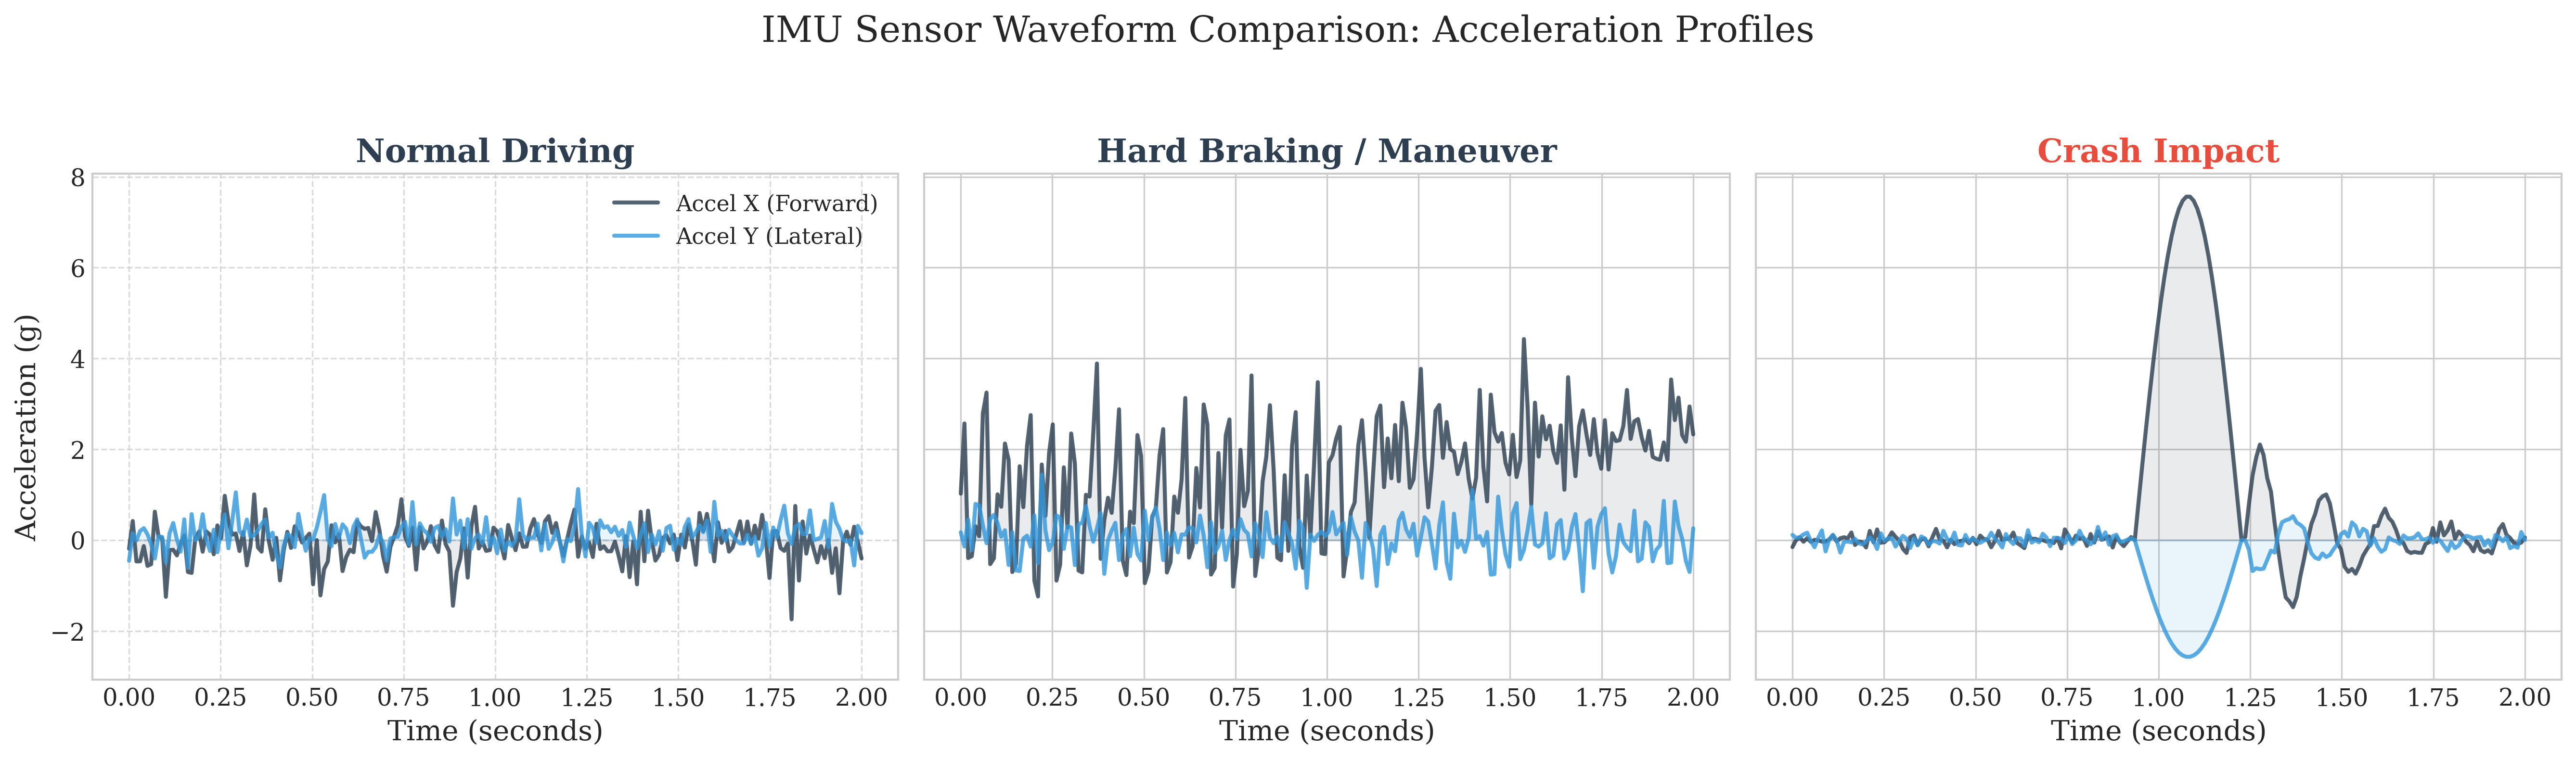


--- 2. Class Distribution ---


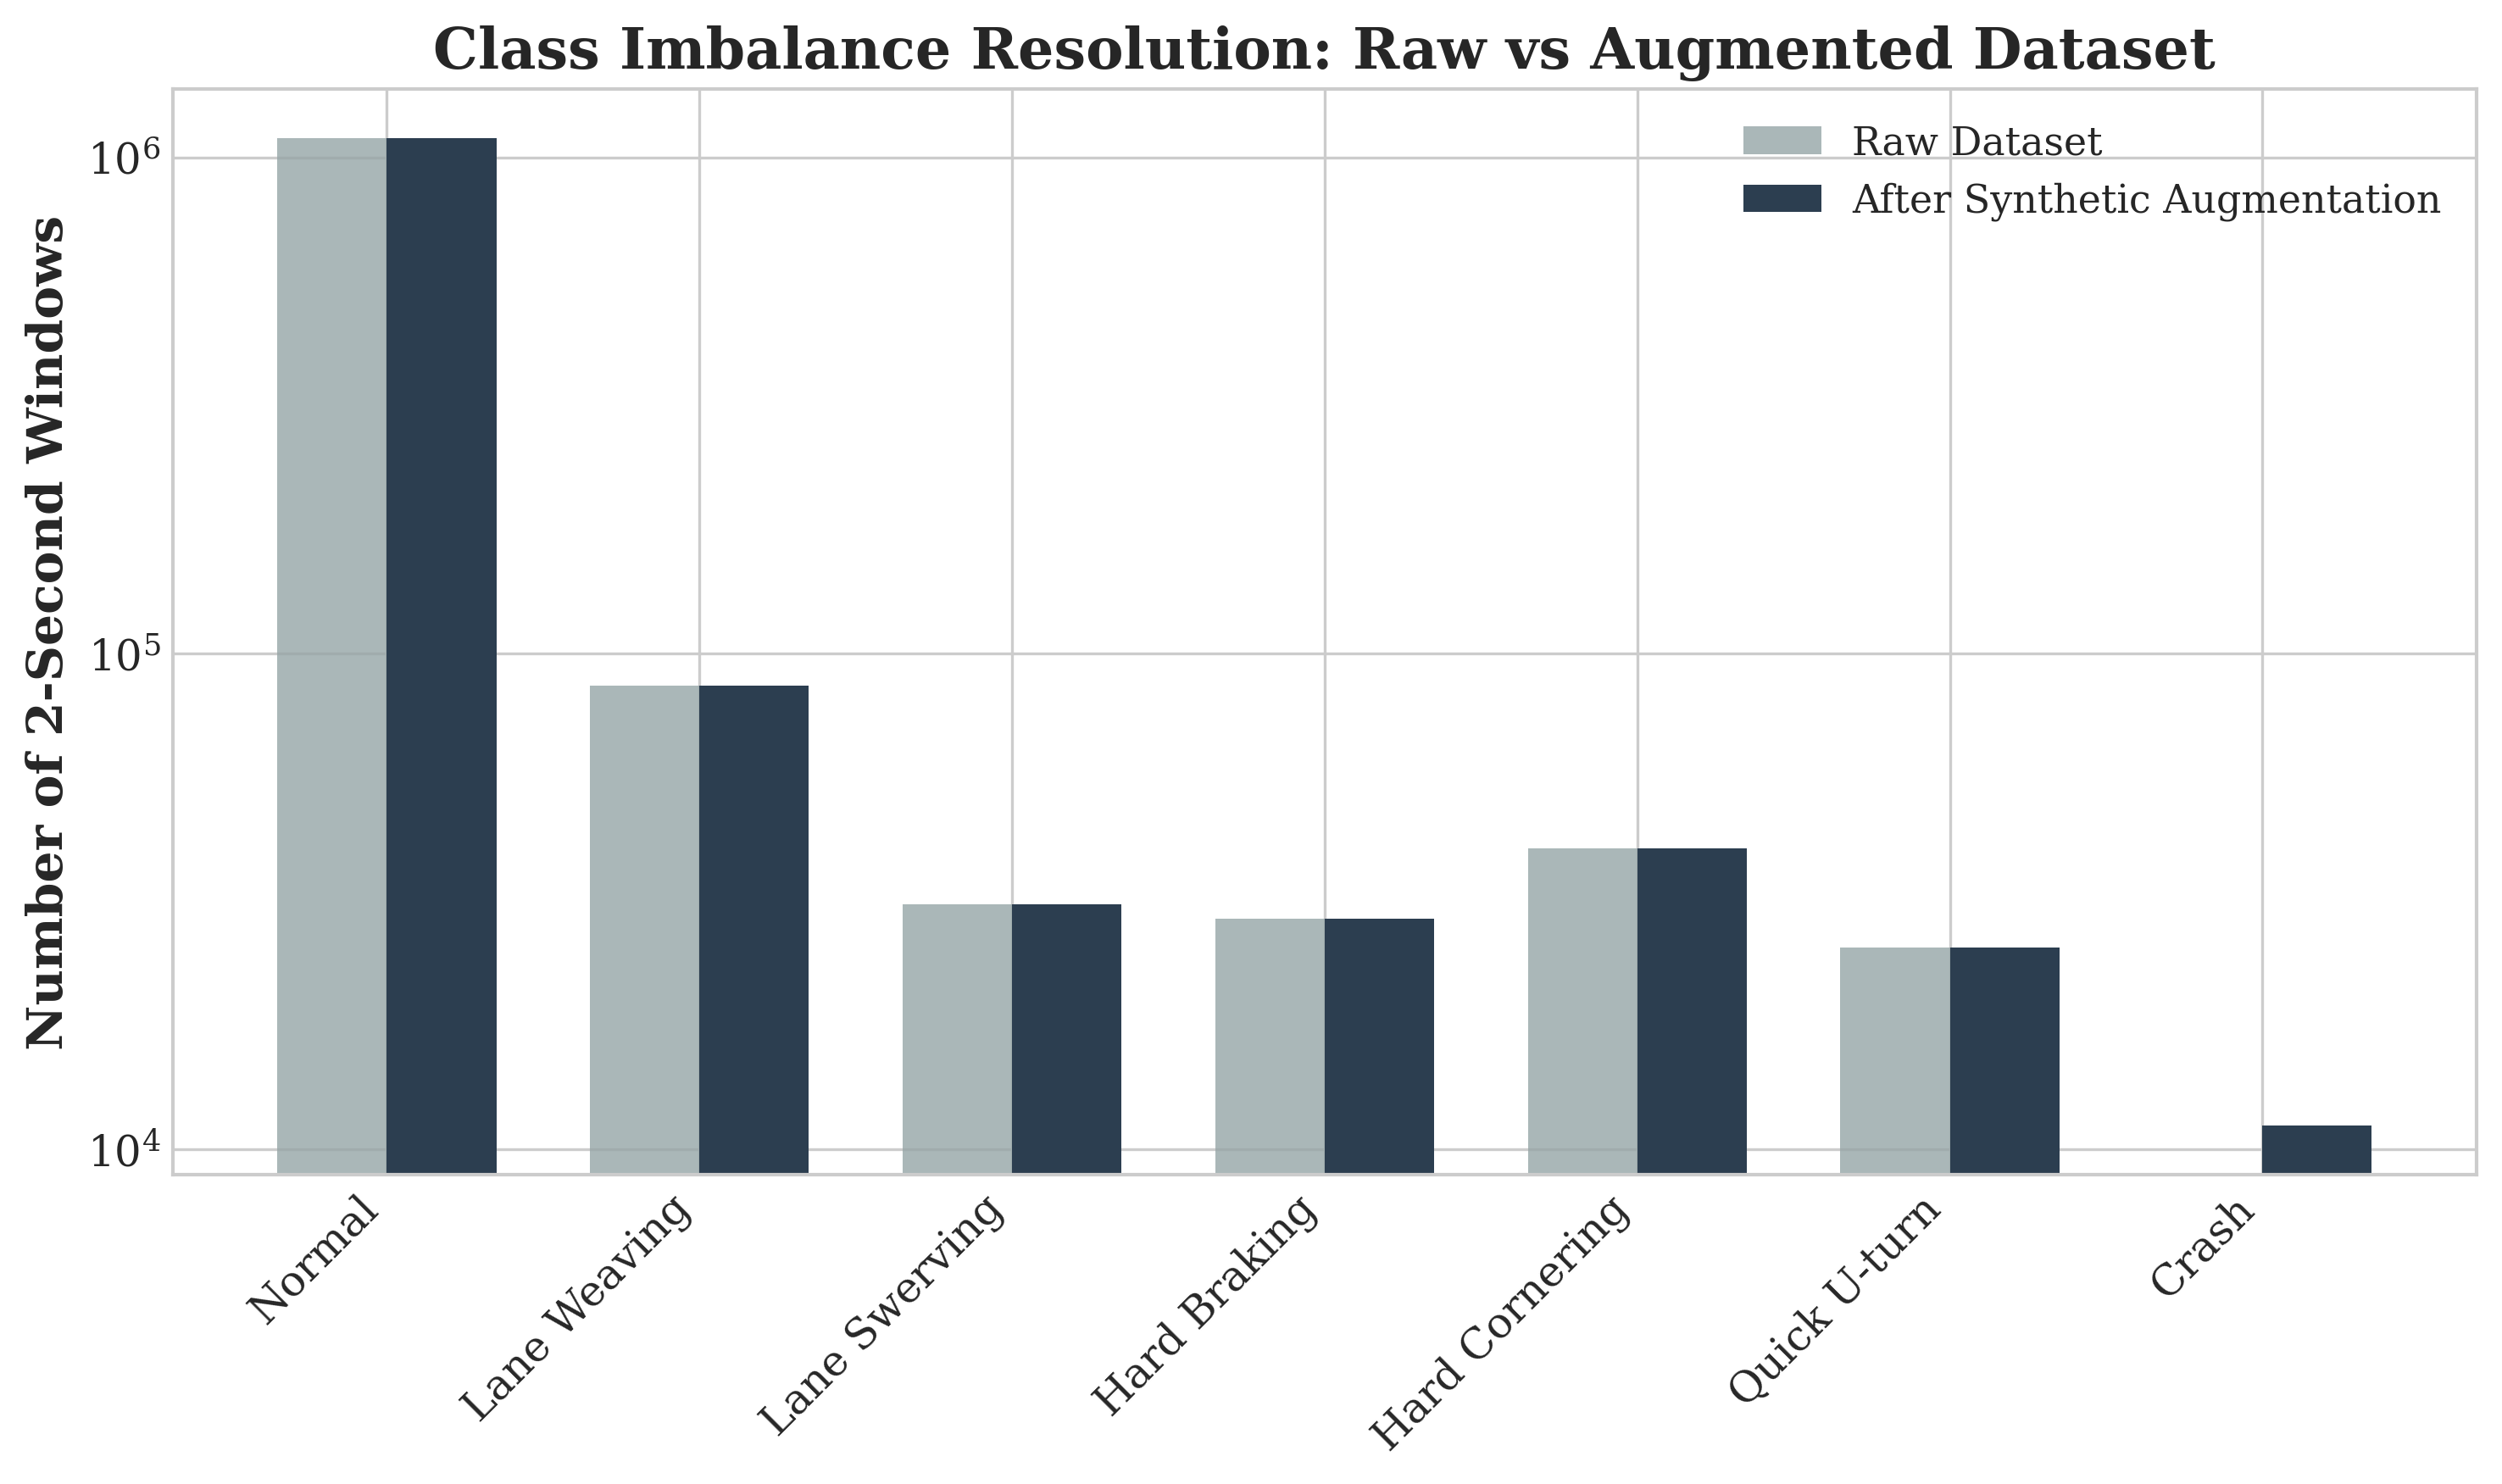


--- 3. Feature Boxplots ---


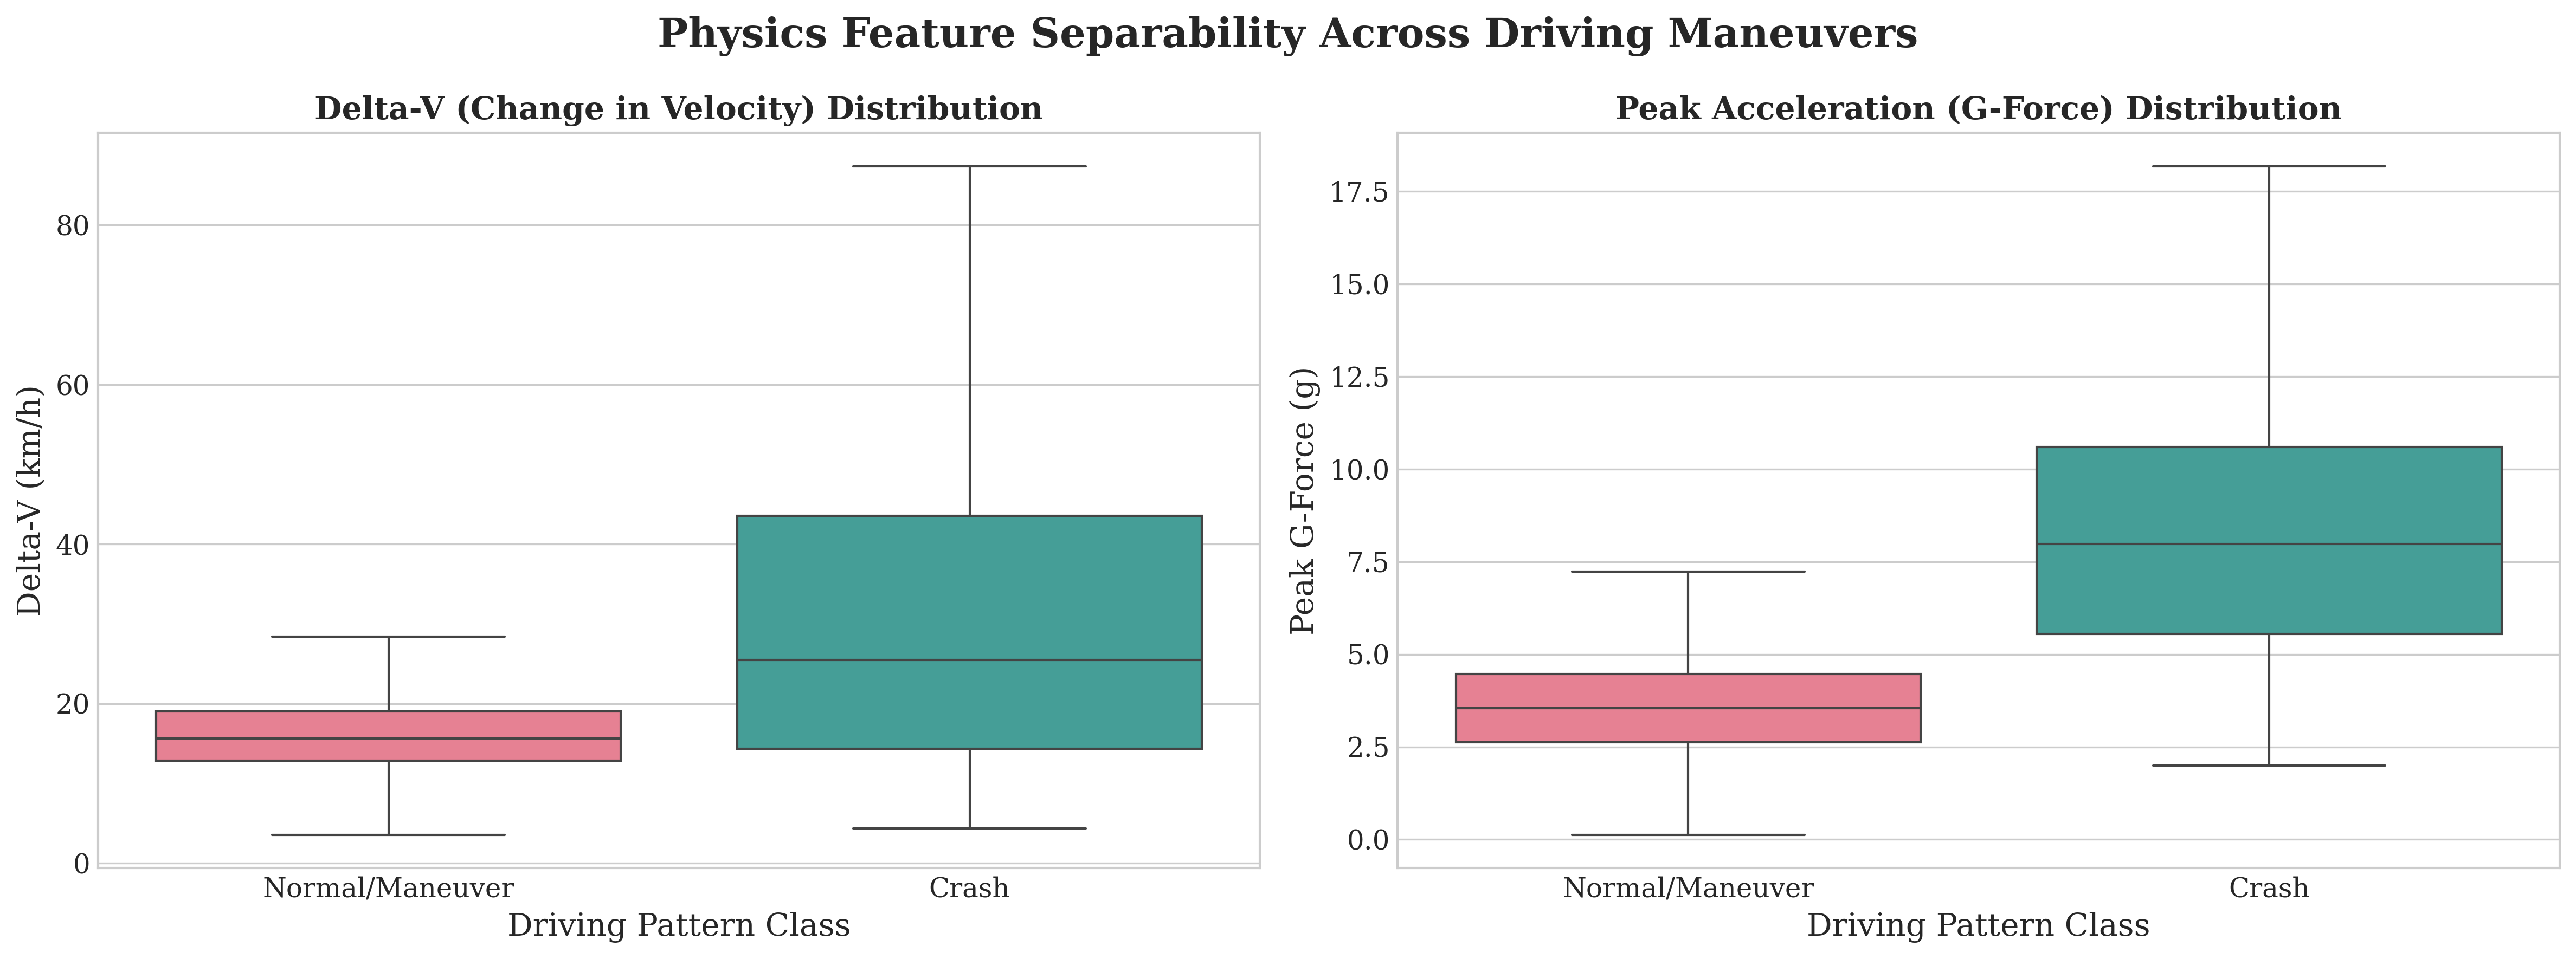


--- 4. Correlation Heatmap ---


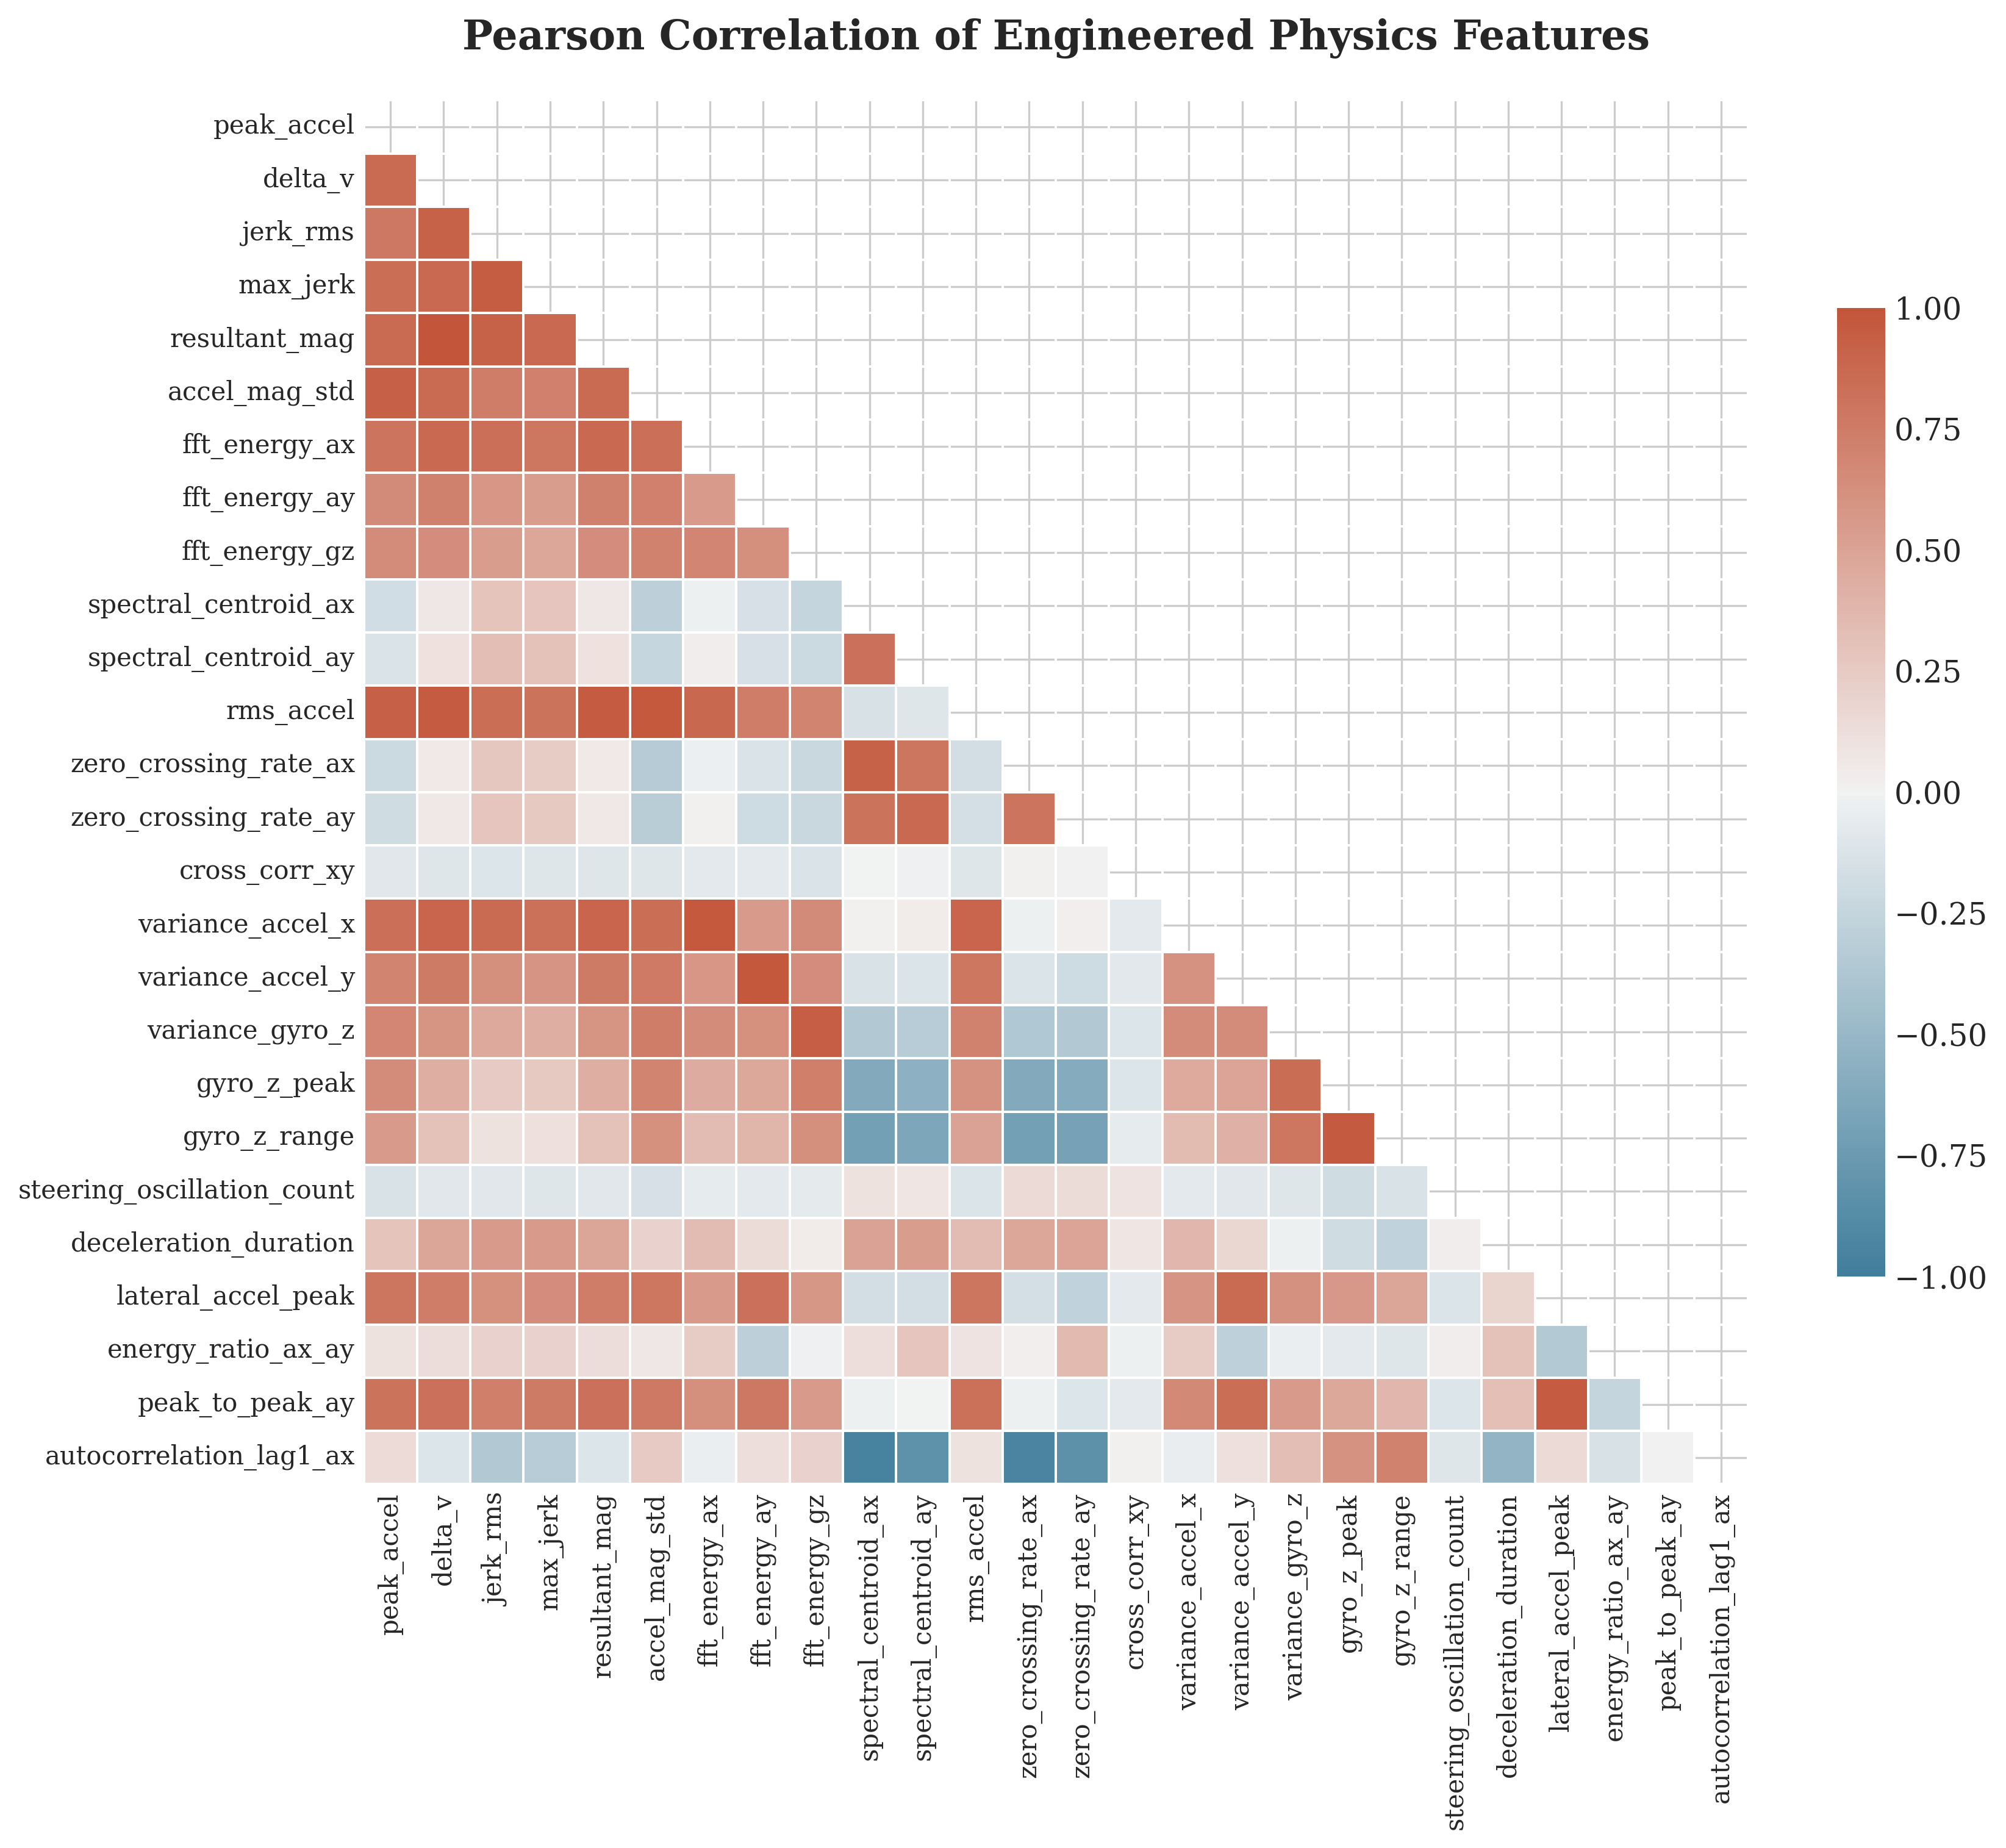

In [7]:
!python src/data/eda.py

from IPython.display import Image, display

print("\n--- 1. Waveform Comparison ---")
display(Image("outputs/plots/eda/01_waveform_comparison.png"))
print("\n--- 2. Class Distribution ---")
display(Image("outputs/plots/eda/02_class_distribution.png"))
print("\n--- 3. Feature Boxplots ---")
display(Image("outputs/plots/eda/03_feature_boxplots.png"))
print("\n--- 4. Correlation Heatmap ---")
display(Image("outputs/plots/eda/04_correlation_heatmap.png"))

## 6. Phase-1: Rash Driving Classifier (Auto-Ensemble Evaluation)

In [8]:
!python src/models/evaluate_multiclass_baselines.py

[IntelliCrash] Global random seed set to 42 for 100% reproducible results.
Loading engineered features and metadata...
  Final dataset: 26,088 samples, 6 classes
  Class distribution: {np.int64(0): np.int64(9086), np.int64(1): np.int64(8391), np.int64(2): np.int64(1974), np.int64(3): np.int64(1549), np.int64(4): np.int64(3308), np.int64(5): np.int64(1780)}

  Training: 20,870 samples | Testing: 5,218 samples
  Number of classes: 6

[1/12] Running XGBoost Hyperparameter Tuning (RandomizedSearchCV)...
  Best XGBoost params: {'colsample_bytree': np.float64(0.6259568988435926), 'gamma': np.float64(0.12695770696717235), 'learning_rate': np.float64(0.05937521256772024), 'max_depth': 9, 'min_child_weight': 2, 'n_estimators': 586, 'reg_alpha': np.float64(0.30087830981676966), 'reg_lambda': np.float64(1.0696809887549352), 'subsample': np.float64(0.6147547789418131)}
  Best CV F1 (macro): 0.7926

[1/12] Training XGBoost (Default)...
  => Accuracy: 0.7079 | F1 (macro): 0.6644

[2/12] Training XGB

## 7. Phase-2: Bi-LSTM Crash Detection + ONNX Export

In [9]:
!python src/models/train_bilstm.py --epochs 10

[IntelliCrash] Global random seed set to 42 for 100% reproducible results.
Using device: cuda
Loading augmented IMU dataset...
[IntelliCrash] Global random seed set to 42 for 100% reproducible results.
Using device: cuda
Loading augmented IMU dataset...
Extracting features for 37,268 windows (this may take a minute)...
Extracting features:   2% 669/37268 [00:00<00:22, 1625.95win/s]Extracting features for 37,268 windows (this may take a minute)...
Extracting features: 100% 37268/37268 [00:26<00:00, 1419.53win/s]
Extracting features: 100% 37268/37268 [00:26<00:00, 1419.53win/s]
Final input shape: (37268, 200, 32)
Final input shape: (37268, 200, 32)
Splits - Train: 26086, Val: 5591, Test: 5591
Splits - Train: 26086, Val: 5591, Test: 5591
Epoch 01: Train Loss=0.0163 Acc=0.9617 | Val Loss=0.0129 Acc=0.9642
  -> Saved new best model
Epoch 01: Train Loss=0.0163 Acc=0.9617 | Val Loss=0.0129 Acc=0.9642
  -> Saved new best model
Epoch 02: Train Loss=0.0088 Acc=0.9806 | Val Loss=0.0054 Acc=0.9871

## 8. Baseline Comparison (TABLE 1)

In [10]:
!python src/models/run_baselines.py

import pandas as pd
baseline_df = pd.read_csv("outputs/reports/baseline_comparison.csv")
display(baseline_df)

Loading augmented IMU dataset...
Extracting features for 37,268 windows...
Extracting features: 100% 37268/37268 [00:24<00:00, 1523.54win/s]
  Combined features: 32 per timestep (6 raw + 26 engineered)
Train: 26,086, Test: 5,591
Training baselines on cuda...

Training Random Forest...
Training 1D CNN...
Training Vanilla LSTM...
Training LSTM Autoencoder...

Evaluating trained Bi-LSTM (IntelliCrash)...

                        Architectural Baseline Comparison (Test Set Metrics)
Model                          | Accuracy | Precision | Recall   | F1 Score | AUC-ROC 
---------------------------------------------------------------------------------------------------------
Static Thresholds              |   53.16% |    36.05% |   72.57% |   48.17% |    0.500
Random Forest (18 Features)    |   98.96% |    98.44% |   98.09% |   98.27% |    0.999
1D CNN                         |   96.40% |    98.11% |   89.74% |   93.74% |    0.991
Vanilla LSTM                   |   96.08% |    94.07% |   92.78

,Model,Accuracy,Precision,Recall,F1 Score,AUC-ROC
0,Static Thresholds,53.16%,36.05%,72.57%,48.17%,0.500
1,Random Forest (18 Features),98.96%,98.44%,98.09%,98.27%,0.999
2,1D CNN,96.40%,98.11%,89.74%,93.74%,0.991
3,Vanilla LSTM,96.08%,94.07%,92.78%,93.43%,0.991
4,Unsupervised LSTM Autoencoder,29.99%,29.99%,100.00%,46.15%,0.685
5,IntelliCrash (Bi-LSTM Gate),99.36%,98.58%,99.28%,98.93%,1.000


## 9. Weight Optimization (TABLE 2)

In [12]:
!python src/models/optimize_weights.py

opt_df = pd.read_csv("outputs/reports/fusion_topsis_ranking.csv")
display(opt_df)

Loading test data...
Loading trained Bi-LSTM model...
Running Inference on Test Set...

        Weight Optimization for Hybrid Fusion Gate
Fusion Weights (ML : CSI) | Recall     | FPR        | F1-Score
-------------------------------------------------------------------------
1.0 : 0.0                 |   99.3%     |    0.6%     |   98.9%
0.8 : 0.2                 |   99.0%     |    0.4%     |   99.0%
0.7 : 0.3                 |   98.9%     |    0.4%     |   99.0%
0.6 : 0.4                 |   98.7%     |    0.2%     |   99.1%
0.5 : 0.5                 |   98.0%     |    0.2%     |   98.8%
0.4 : 0.6                 |   84.0%     |    0.1%     |   91.2%
0.0 : 1.0                 |   30.5%     |    0.1%     |   46.7%

[TOPSIS] Automatically evaluating fusion weights using TOPSIS...

🏆 TOPSIS WINNER (Rank #1 Fusion Weight): 0.5 : 0.5
   Topsis Score: 0.8567
   Saved optimal weights to: /content/IntelliCrash/outputs/reports/optimal_fusion_weights.json


,Fusion Weights (ML:CSI),Recall (%),FPR (%),F1-Score (%),Topsis Score,Rank
0,1.0 : 0.0,99.28,0.61,98.93,0.4102,7
1,0.8 : 0.2,98.99,0.43,98.99,0.5297,6
2,0.7 : 0.3,98.87,0.36,99.01,0.5982,4
3,0.6 : 0.4,98.75,0.23,99.10,0.7509,3
4,0.5 : 0.5,98.03,0.15,98.83,0.8567,1
5,0.4 : 0.6,84.02,0.13,91.17,0.8341,2
6,0.0 : 1.0,30.47,0.05,46.67,0.5896,5


## 10. Ablation Study (TABLE 3)

In [13]:
!python src/models/evaluate_ablation.py --w_ml 0.5 --w_csi 0.5

ablation_df = pd.read_csv("outputs/reports/ablation_study.csv")
display(ablation_df)


[Ablation] Using manually specified weights: 0.5 ML + 0.5 CSI

Loading test data...
Loading trained Bi-LSTM model...
Running Inference on Test Set...

  Ablation Study of the Hybrid Fusion Gate
Architecture Configuration     | Recall       | FPR         
-----------------------------------------------------------------
Physics CSI Gate Only          |  30.47%       |   0.05%
Bi-LSTM Only                   |  99.28%       |   0.61%
Fused (Hybrid Bi-LSTM)         |  98.03%       |   0.15%

=> Table saved to: /content/IntelliCrash/outputs/reports/ablation_study.csv


,Architecture Configuration,Recall (%),FPR (%)
0,Physics CSI Gate Only,30.47,0.05
1,Bi-LSTM Only,99.28,0.61
2,Fused Hybrid (0.5 ML + 0.5 CSI),98.03,0.15


## 11. Evaluation Plots (ROC + Confusion Matrices)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
  Generated Multi-class Evaluation Plots (Best TOPSIS Model).
  Using TOPSIS-optimized weights: 0.5 ML + 0.5 CSI
  Generated Binary Evaluation Plots (Bi-LSTM / Fusion).

Successfully generated all evaluation plots in /content/IntelliCrash/outputs/plots/evaluation

--- Multi-Class ROC Curve (Ensemble Rash Classification) ---


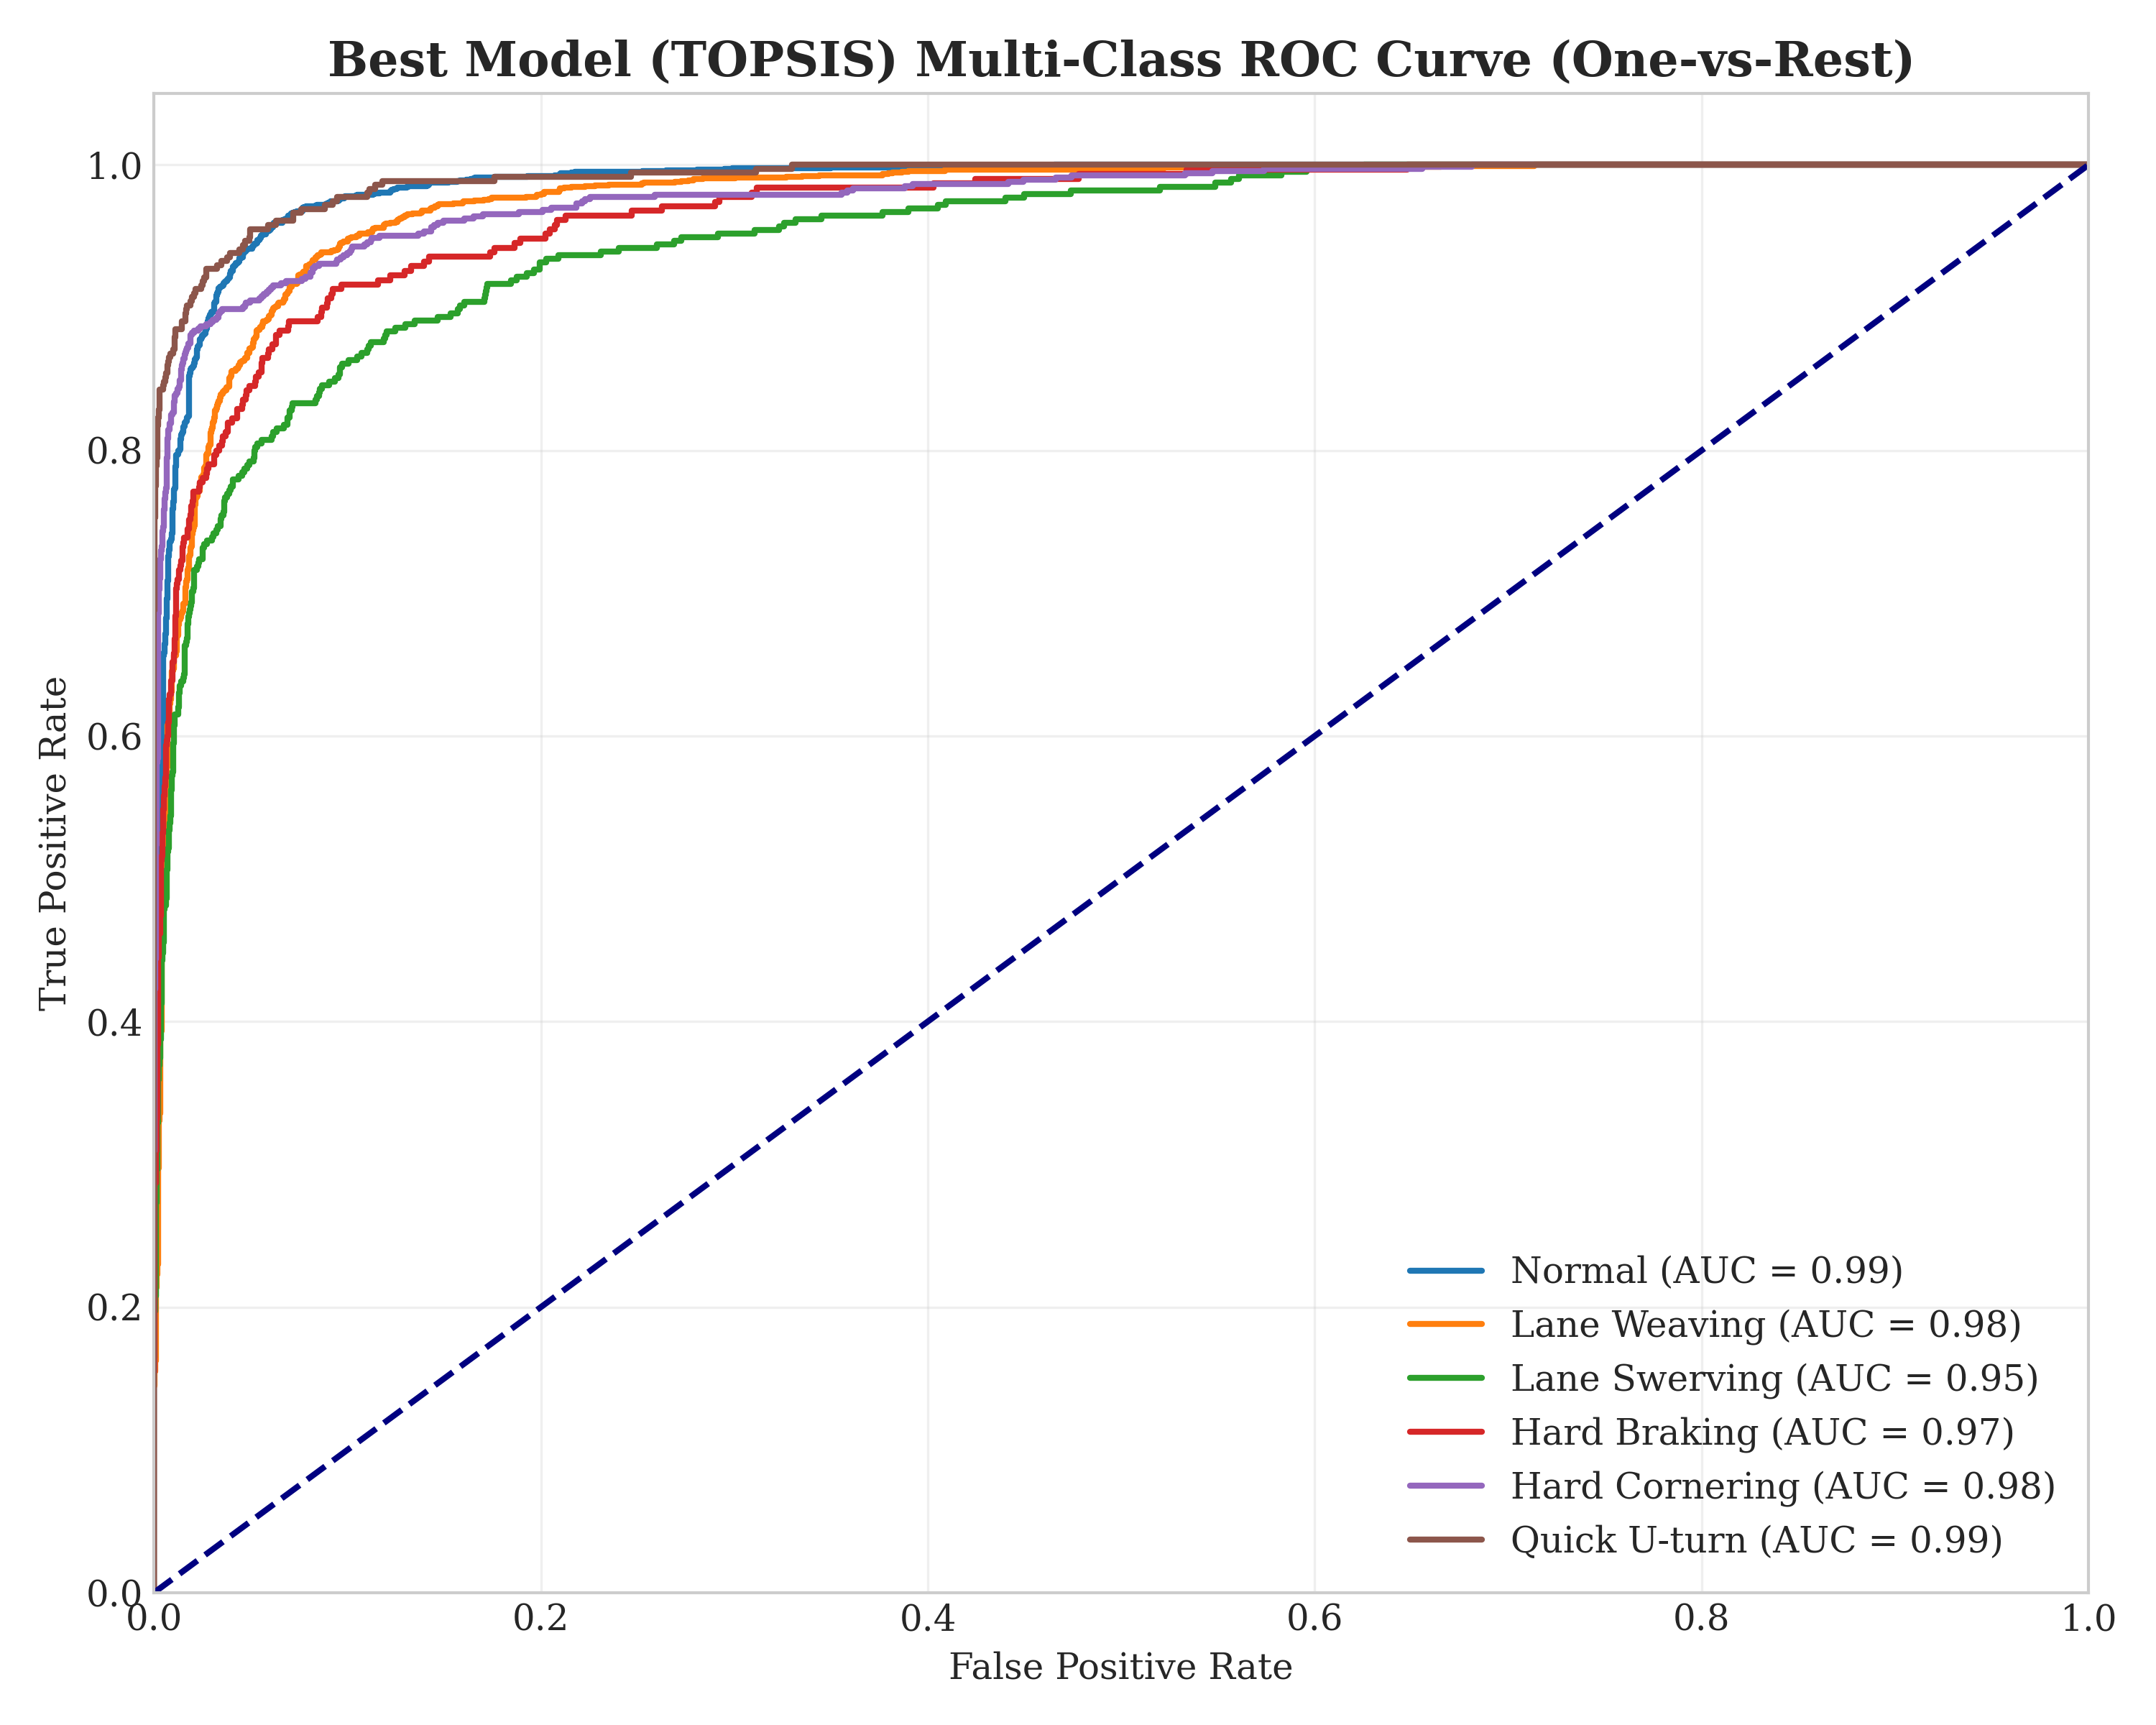


--- Multi-Class Confusion Matrix (Ensemble 6x6) ---


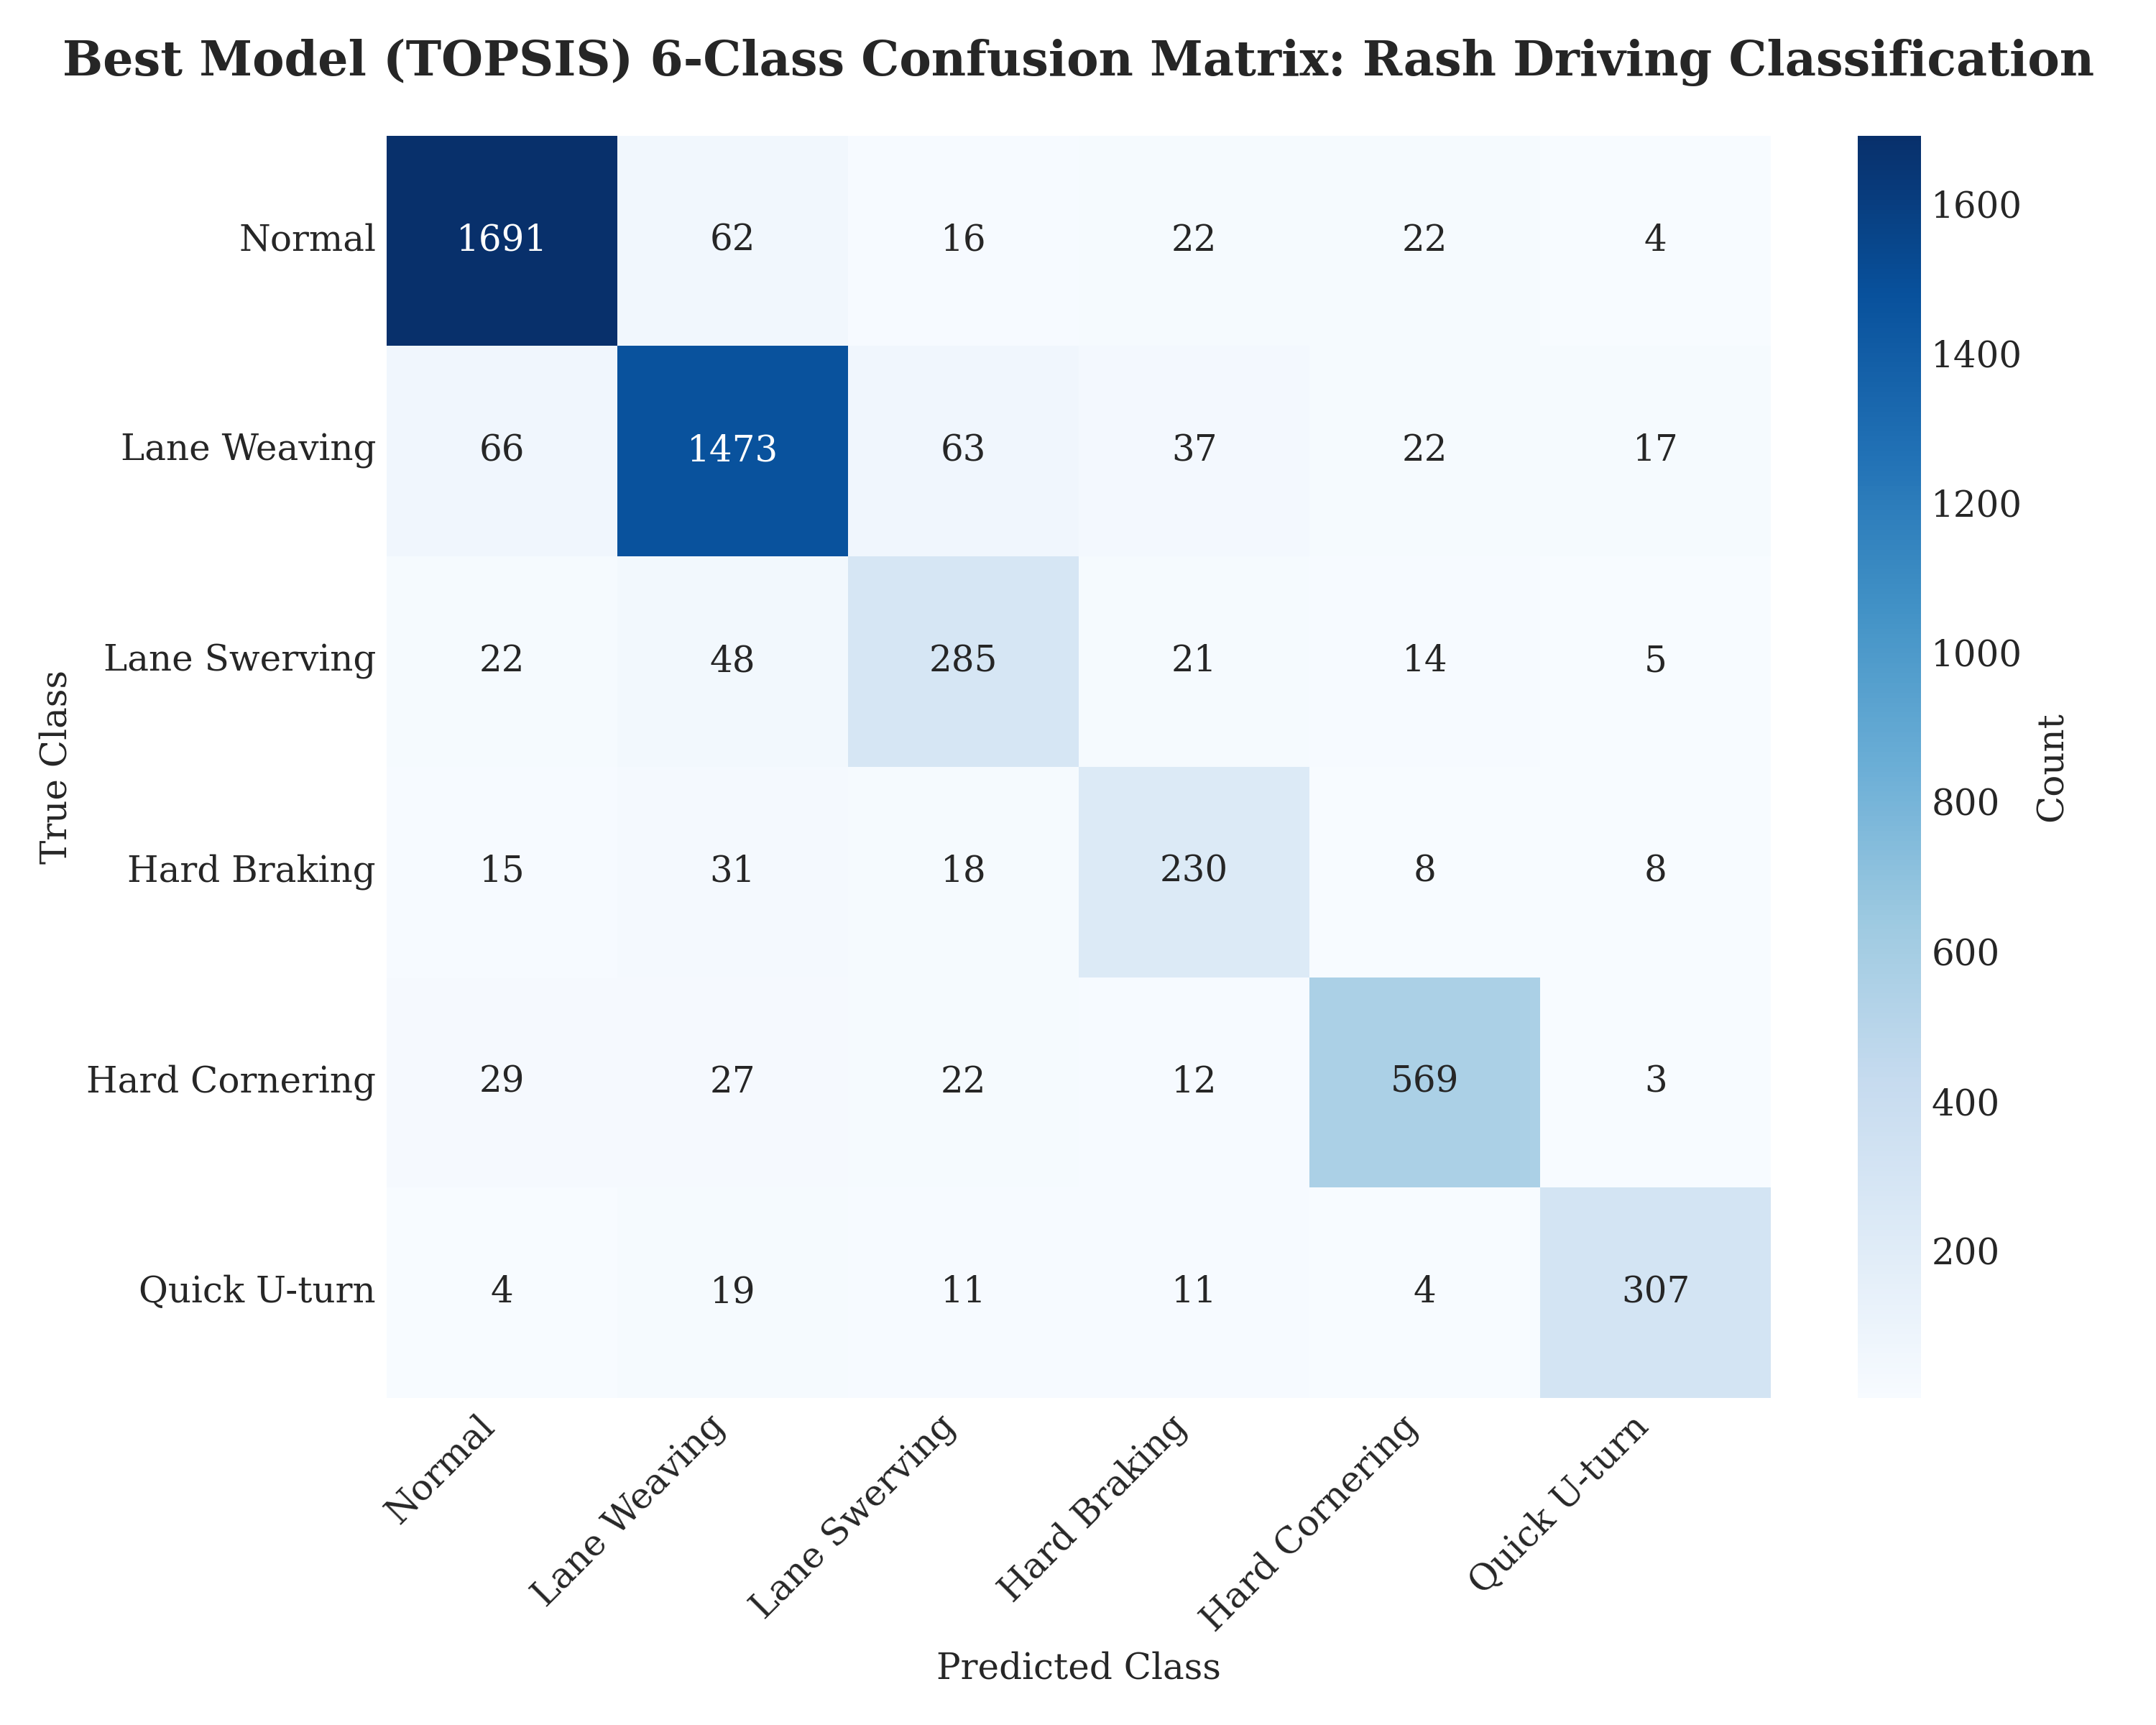


--- Binary ROC Curve (Comparative) ---


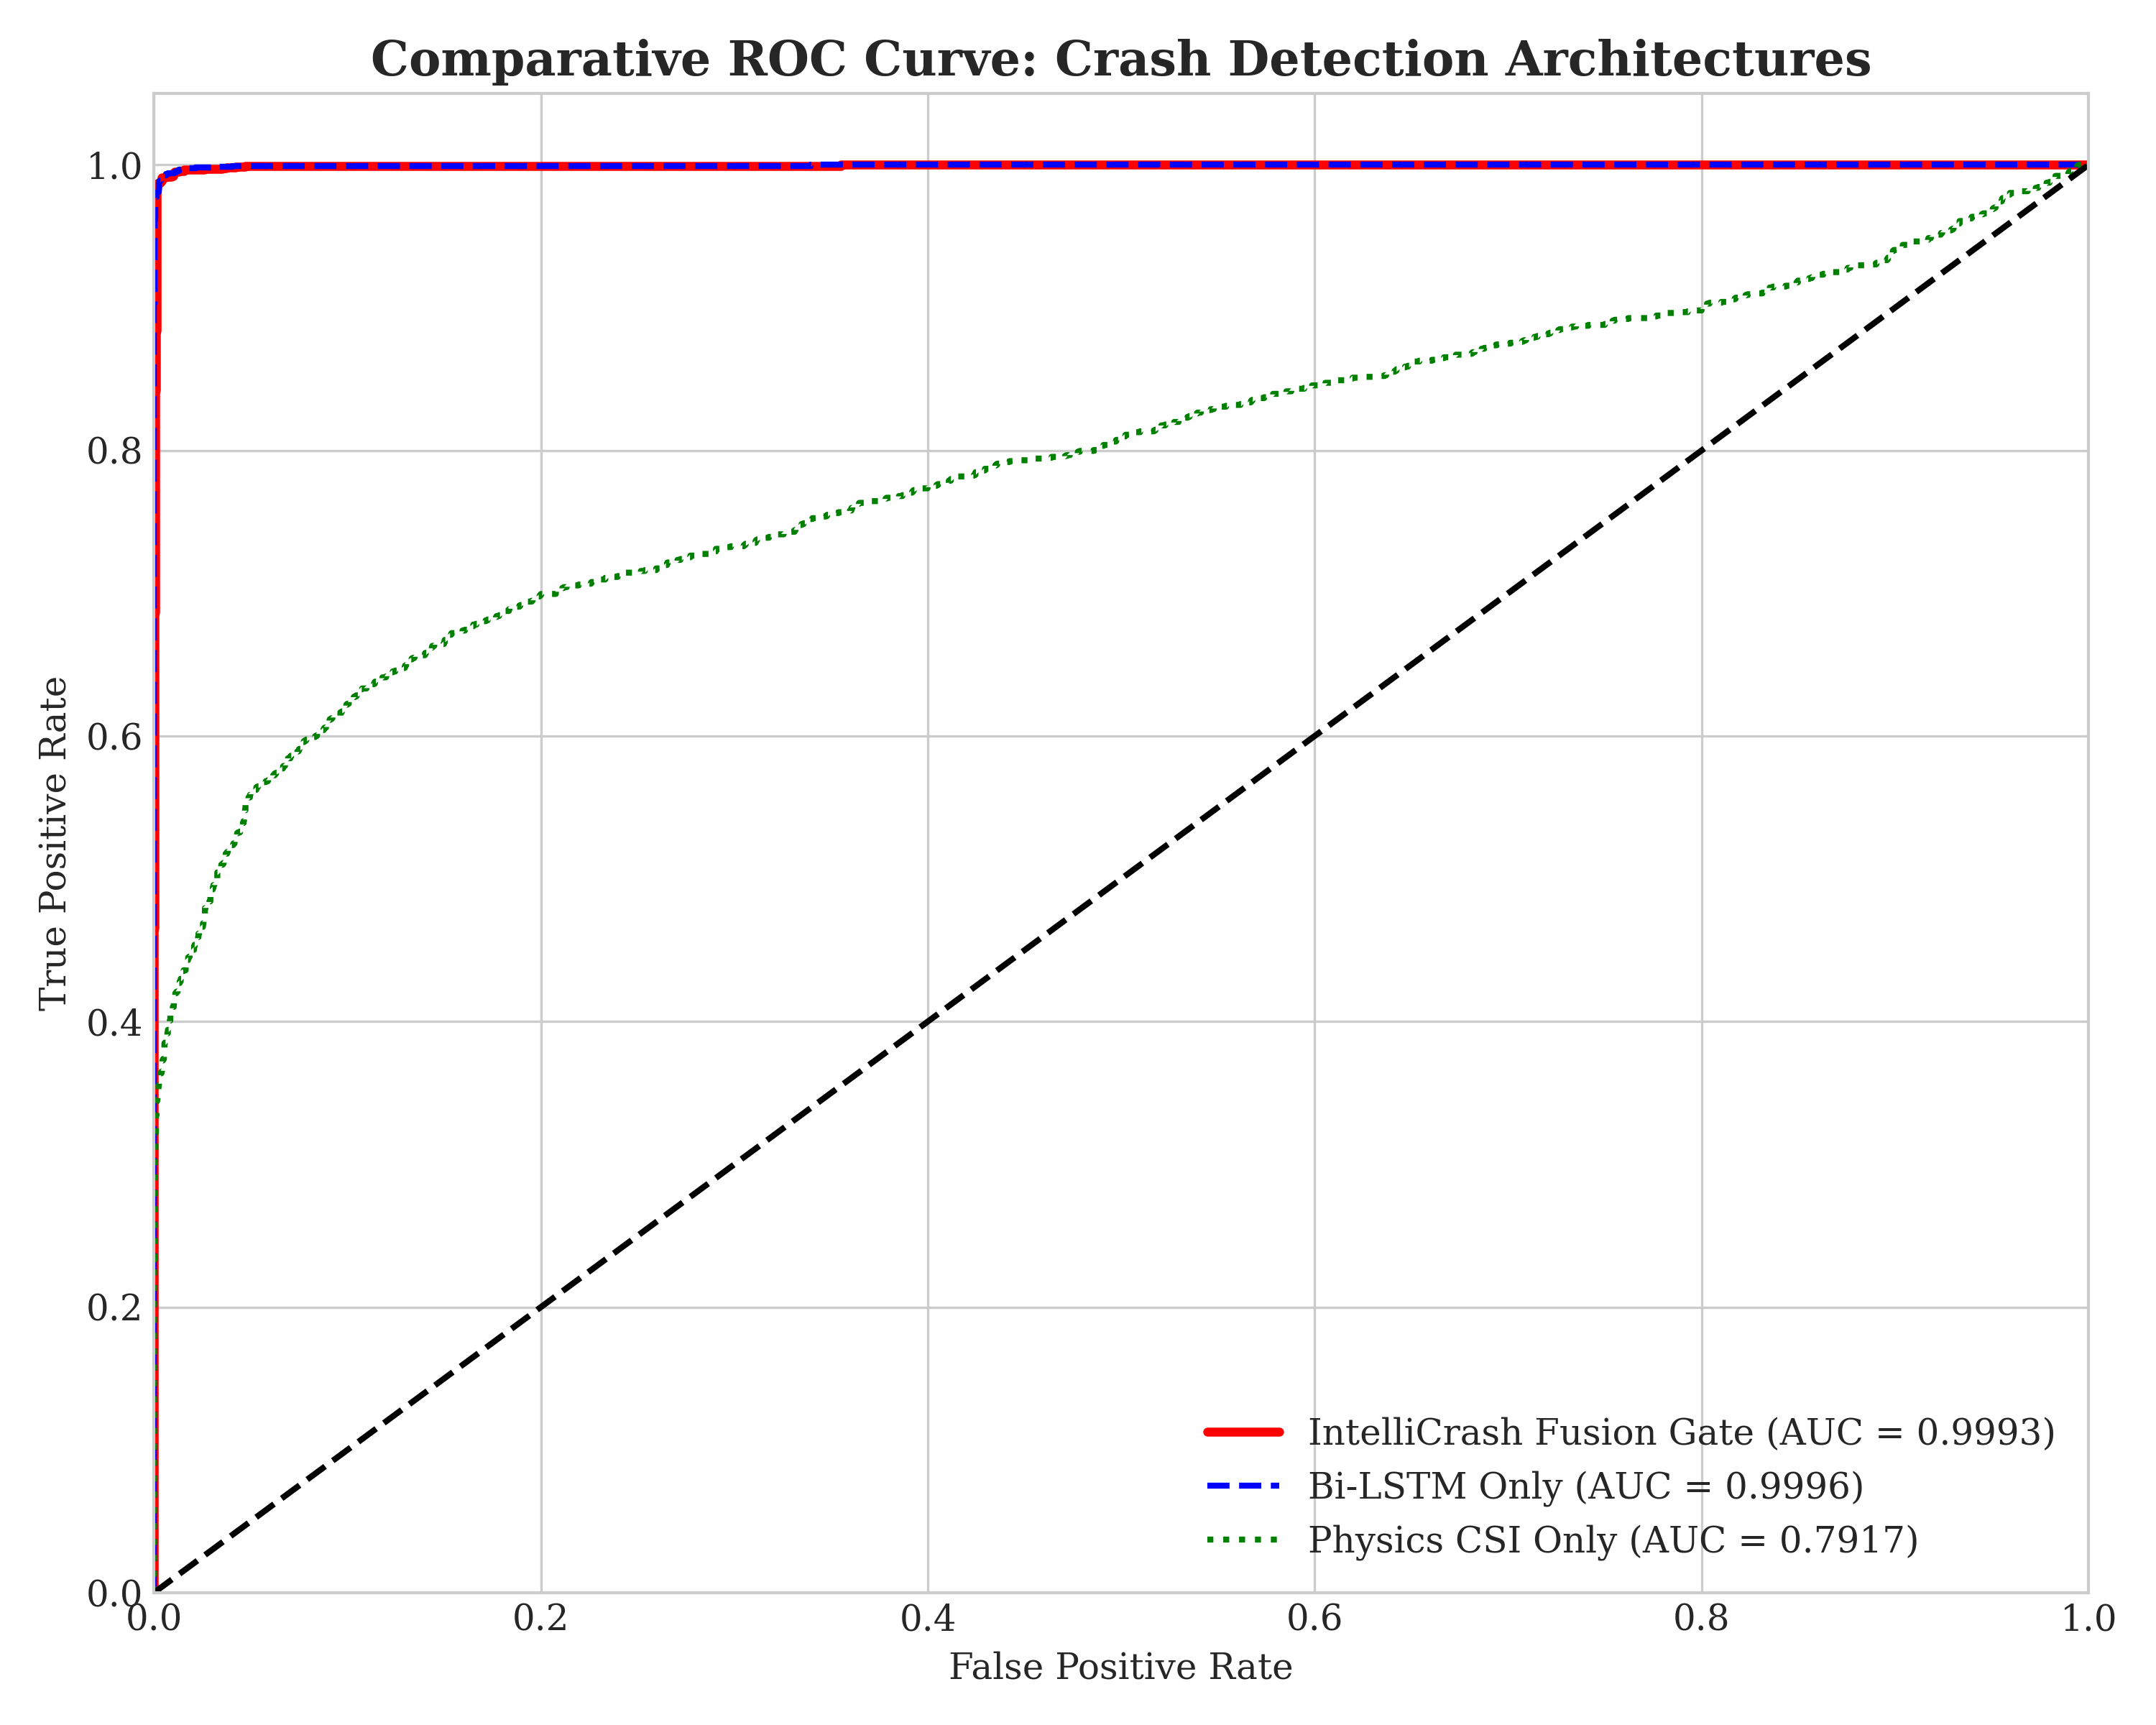


--- Fusion Gate Confusion Matrix (Bi-LSTM + CSI 2x2) ---


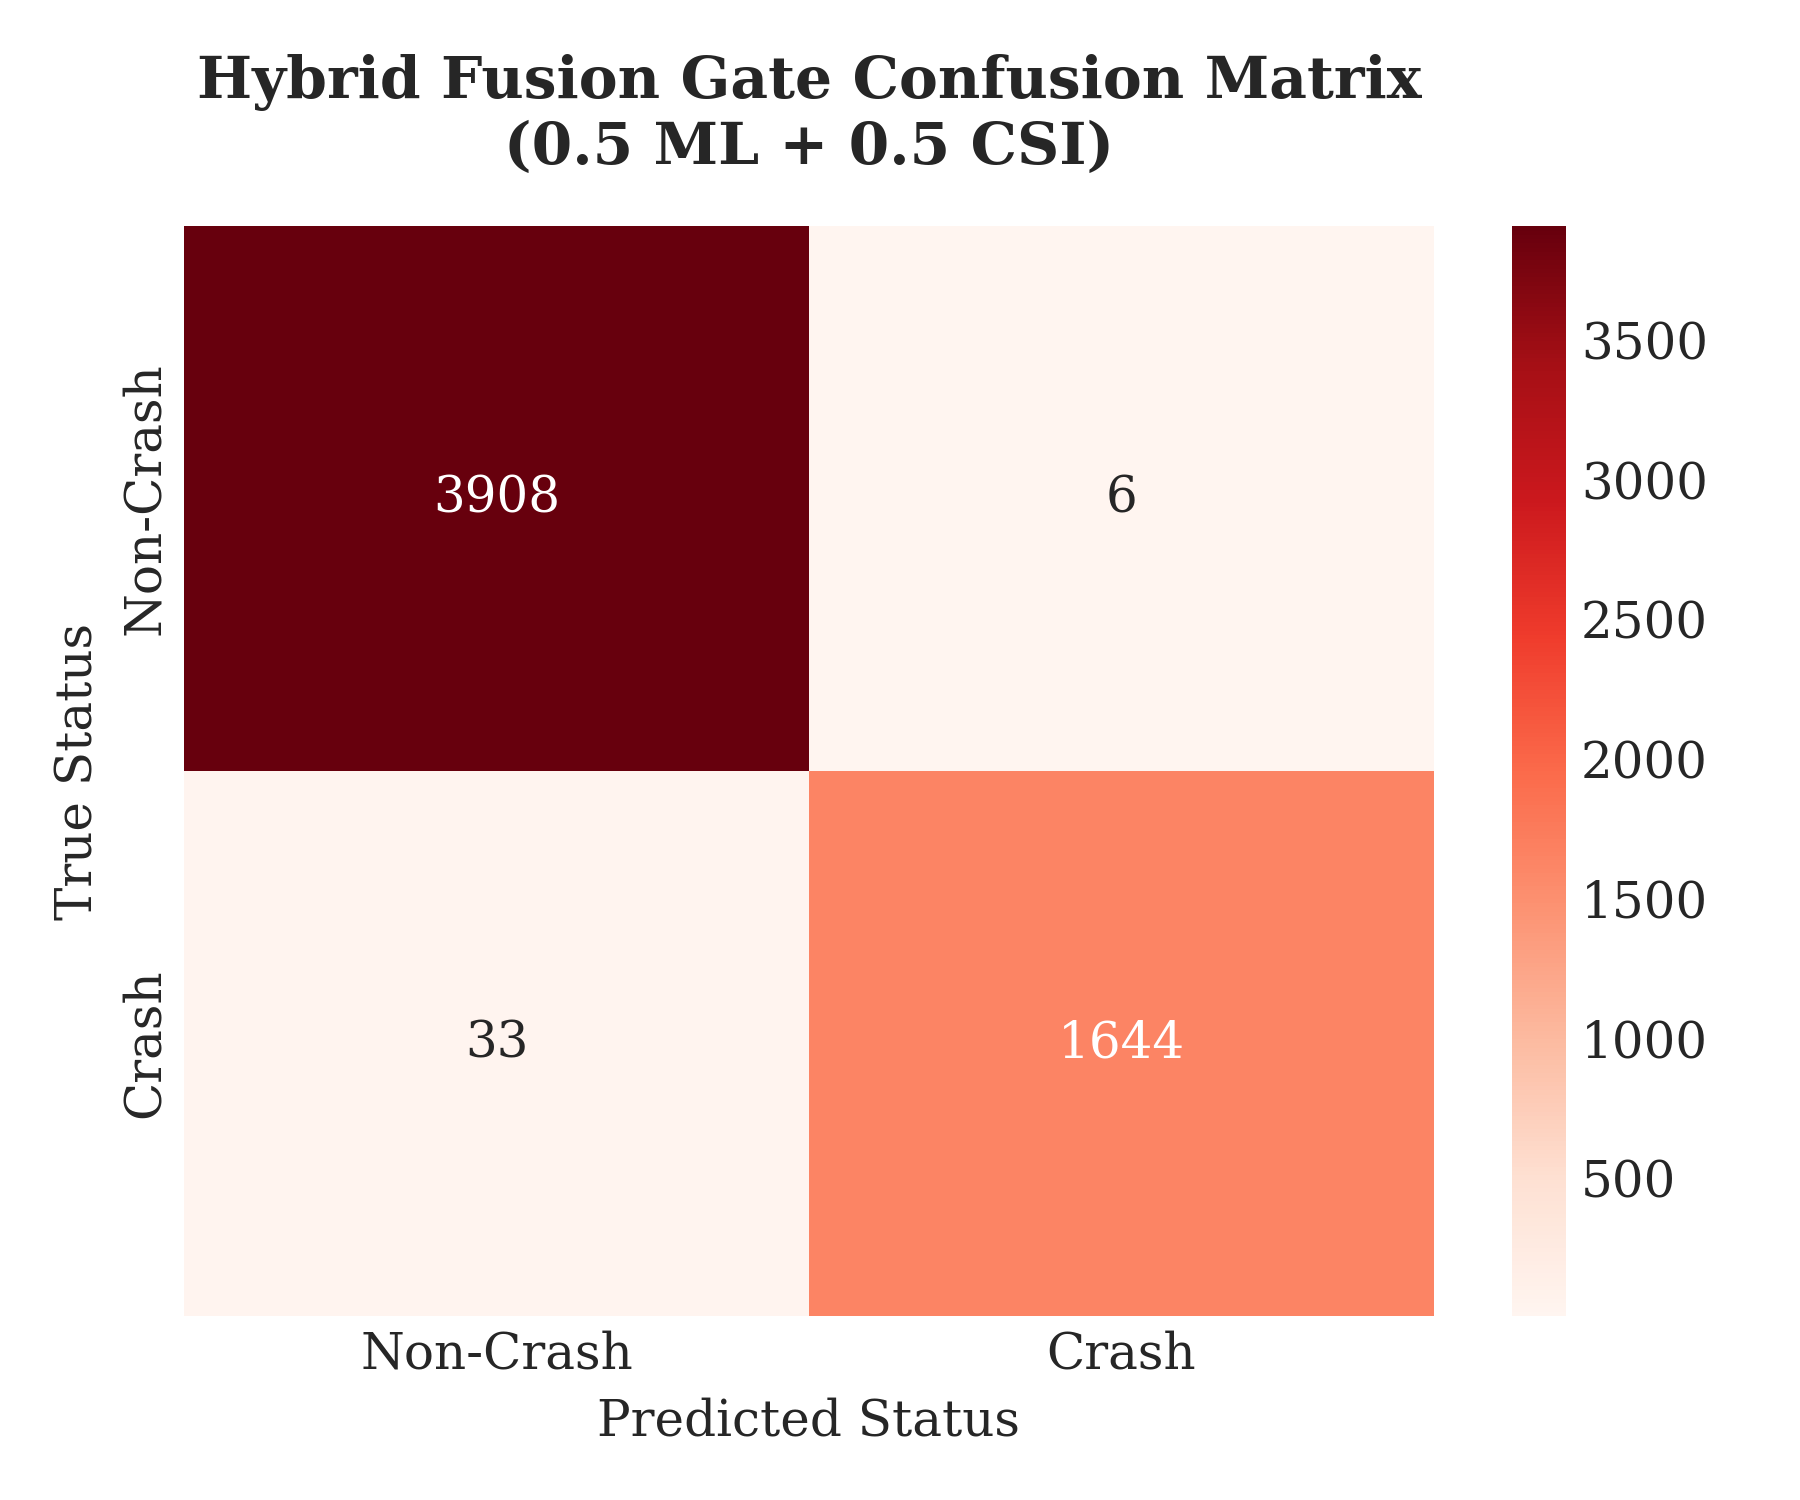

In [15]:
!python src/models/evaluate_plots.py

print("\n--- Multi-Class ROC Curve (Ensemble Rash Classification) ---")
display(Image("outputs/plots/evaluation/best_model_multiclass_roc.png"))

print("\n--- Multi-Class Confusion Matrix (Ensemble 6x6) ---")
display(Image("outputs/plots/evaluation/best_model_6x6_confusion_matrix.png"))

print("\n--- Binary ROC Curve (Comparative) ---")
display(Image("outputs/plots/evaluation/comparative_binary_roc.png"))

print("\n--- Fusion Gate Confusion Matrix (Bi-LSTM + CSI 2x2) ---")
display(Image("outputs/plots/evaluation/fusion_gate_2x2_cm.png"))

## 12. Explainable AI (SHAP)

Loading engineered features and metadata for SHAP background data...
Loading Best Auto-TOPSIS Model...
Calculating SHAP values...
  Using TreeExplainer (fast, exact).
Human-readable forensic PDF report saved to /content/IntelliCrash/outputs/reports/crash_forensic_report.pdf
SHAP Analysis complete. Plots saved to /content/IntelliCrash/outputs/plots/shap

--- SHAP Feature Importance ---


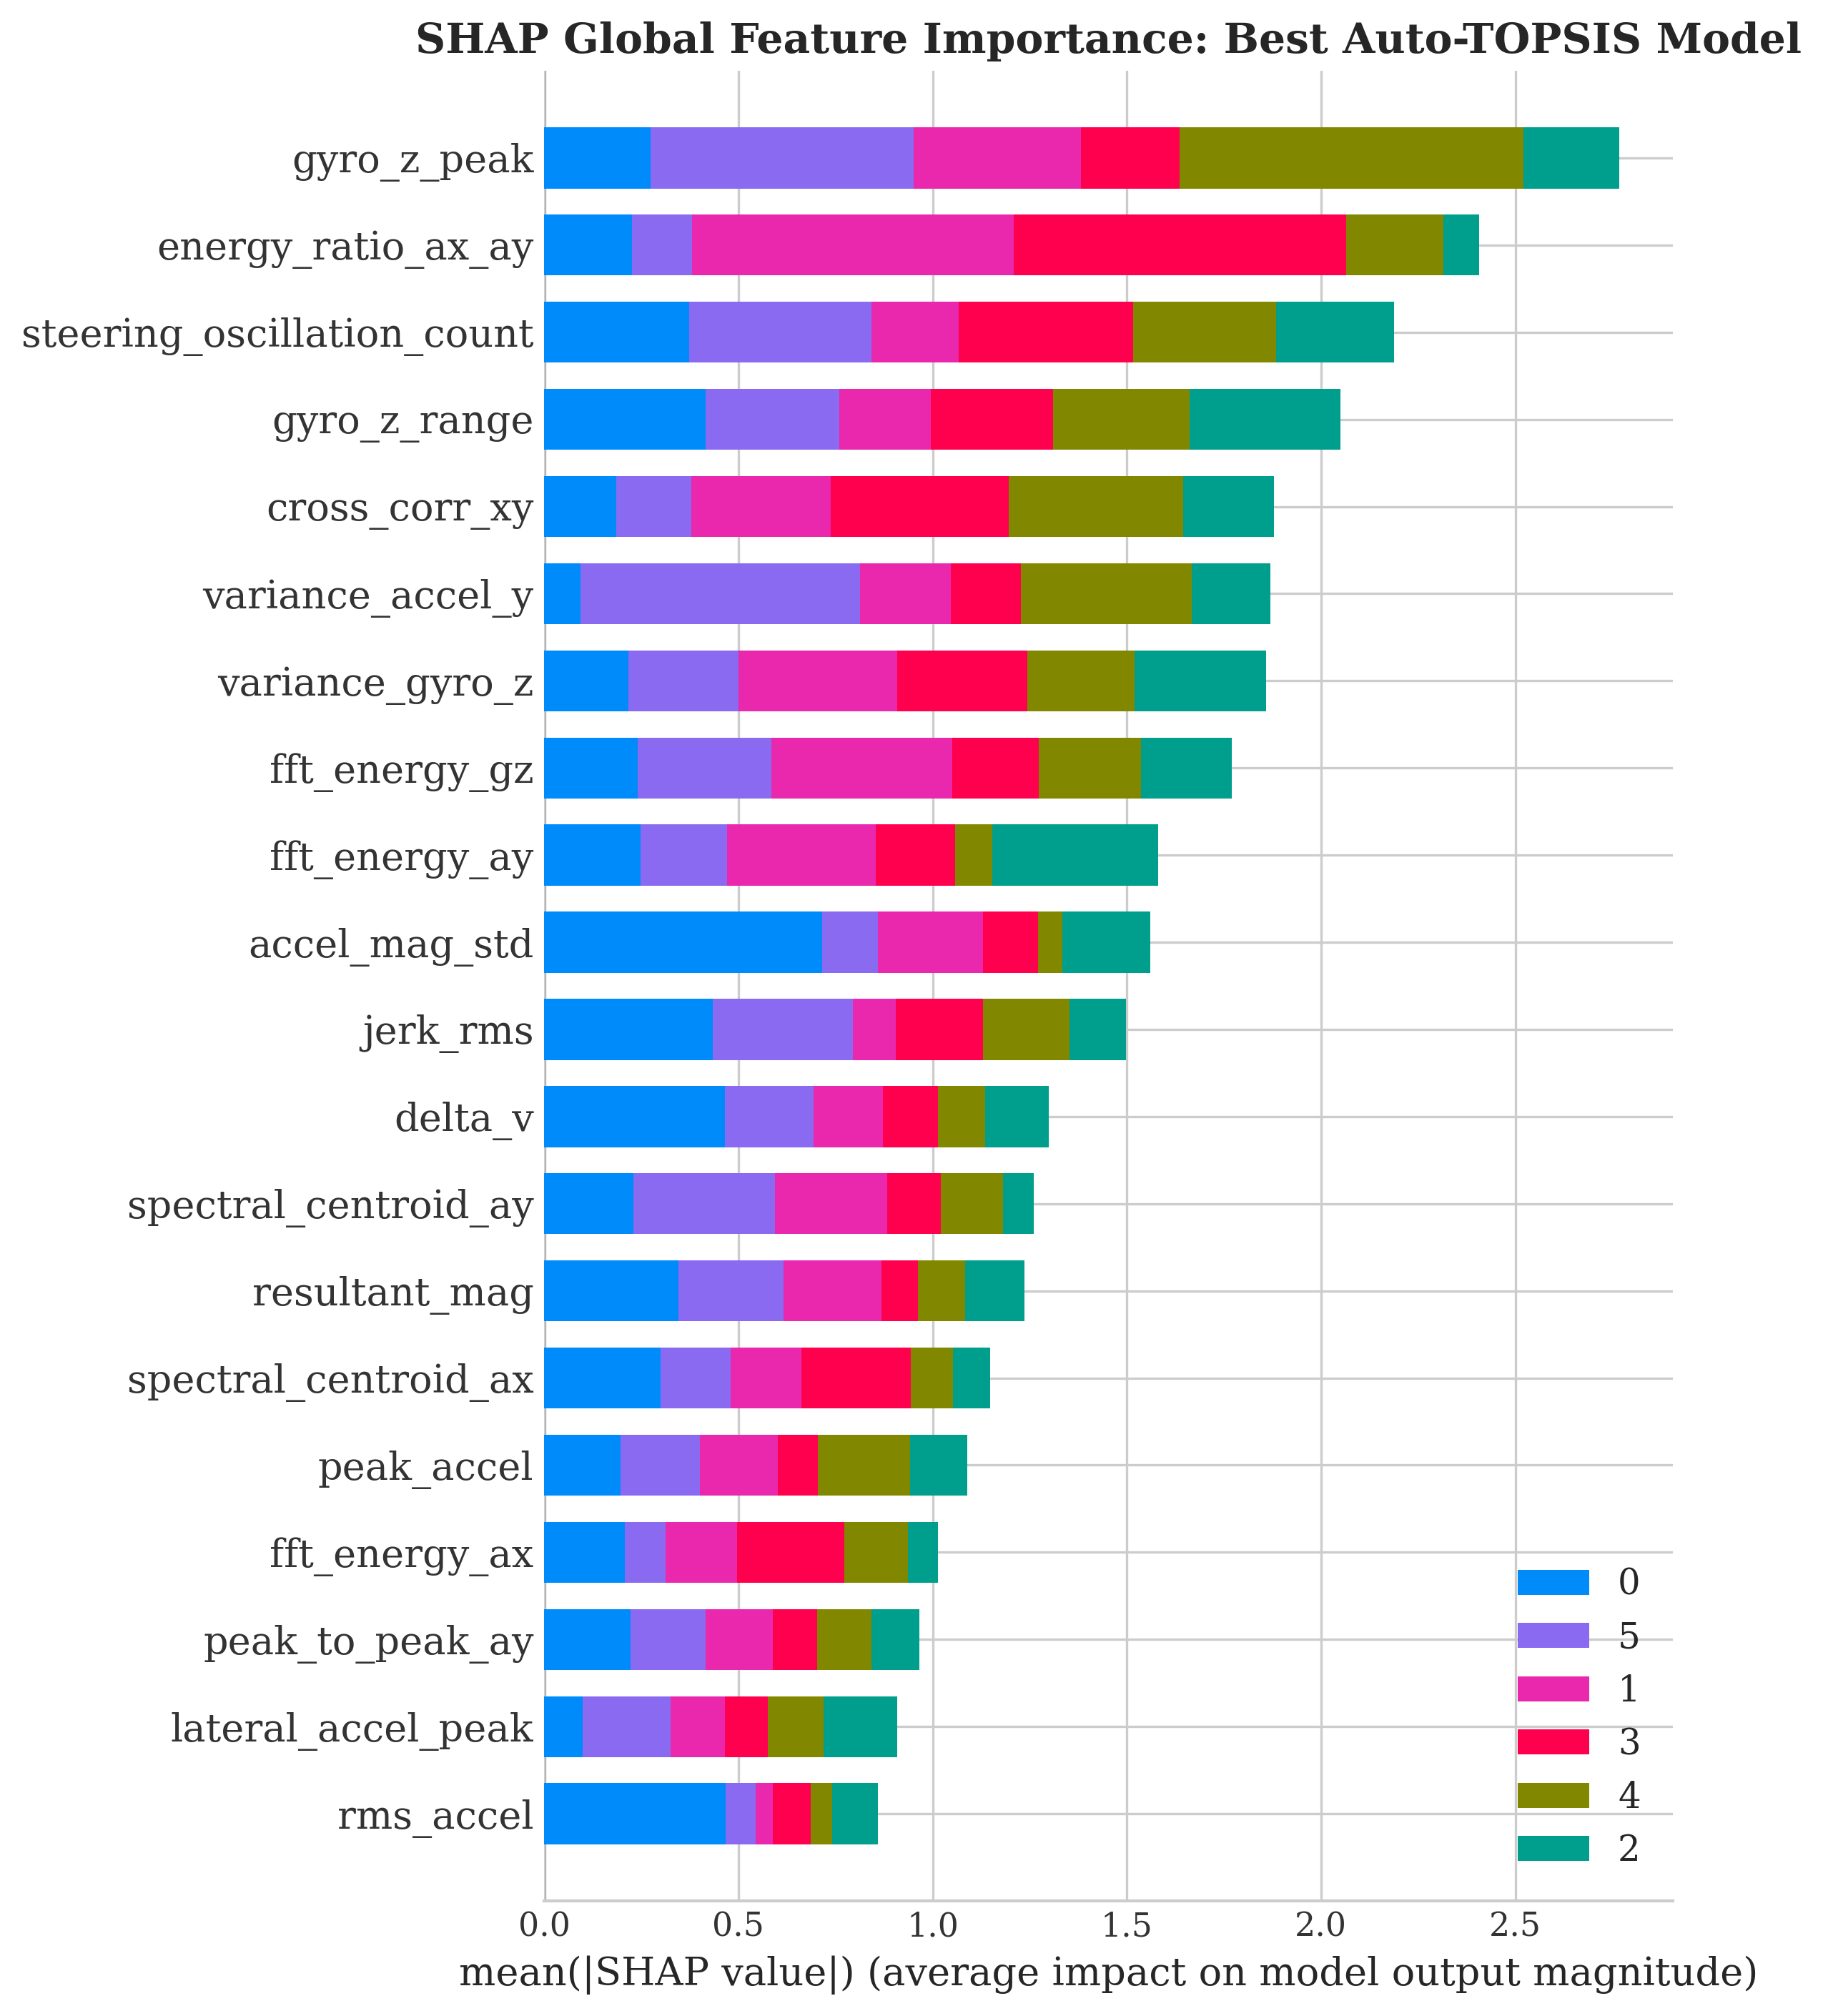


--- SHAP Waterfall Plot (Local Interpretation) ---


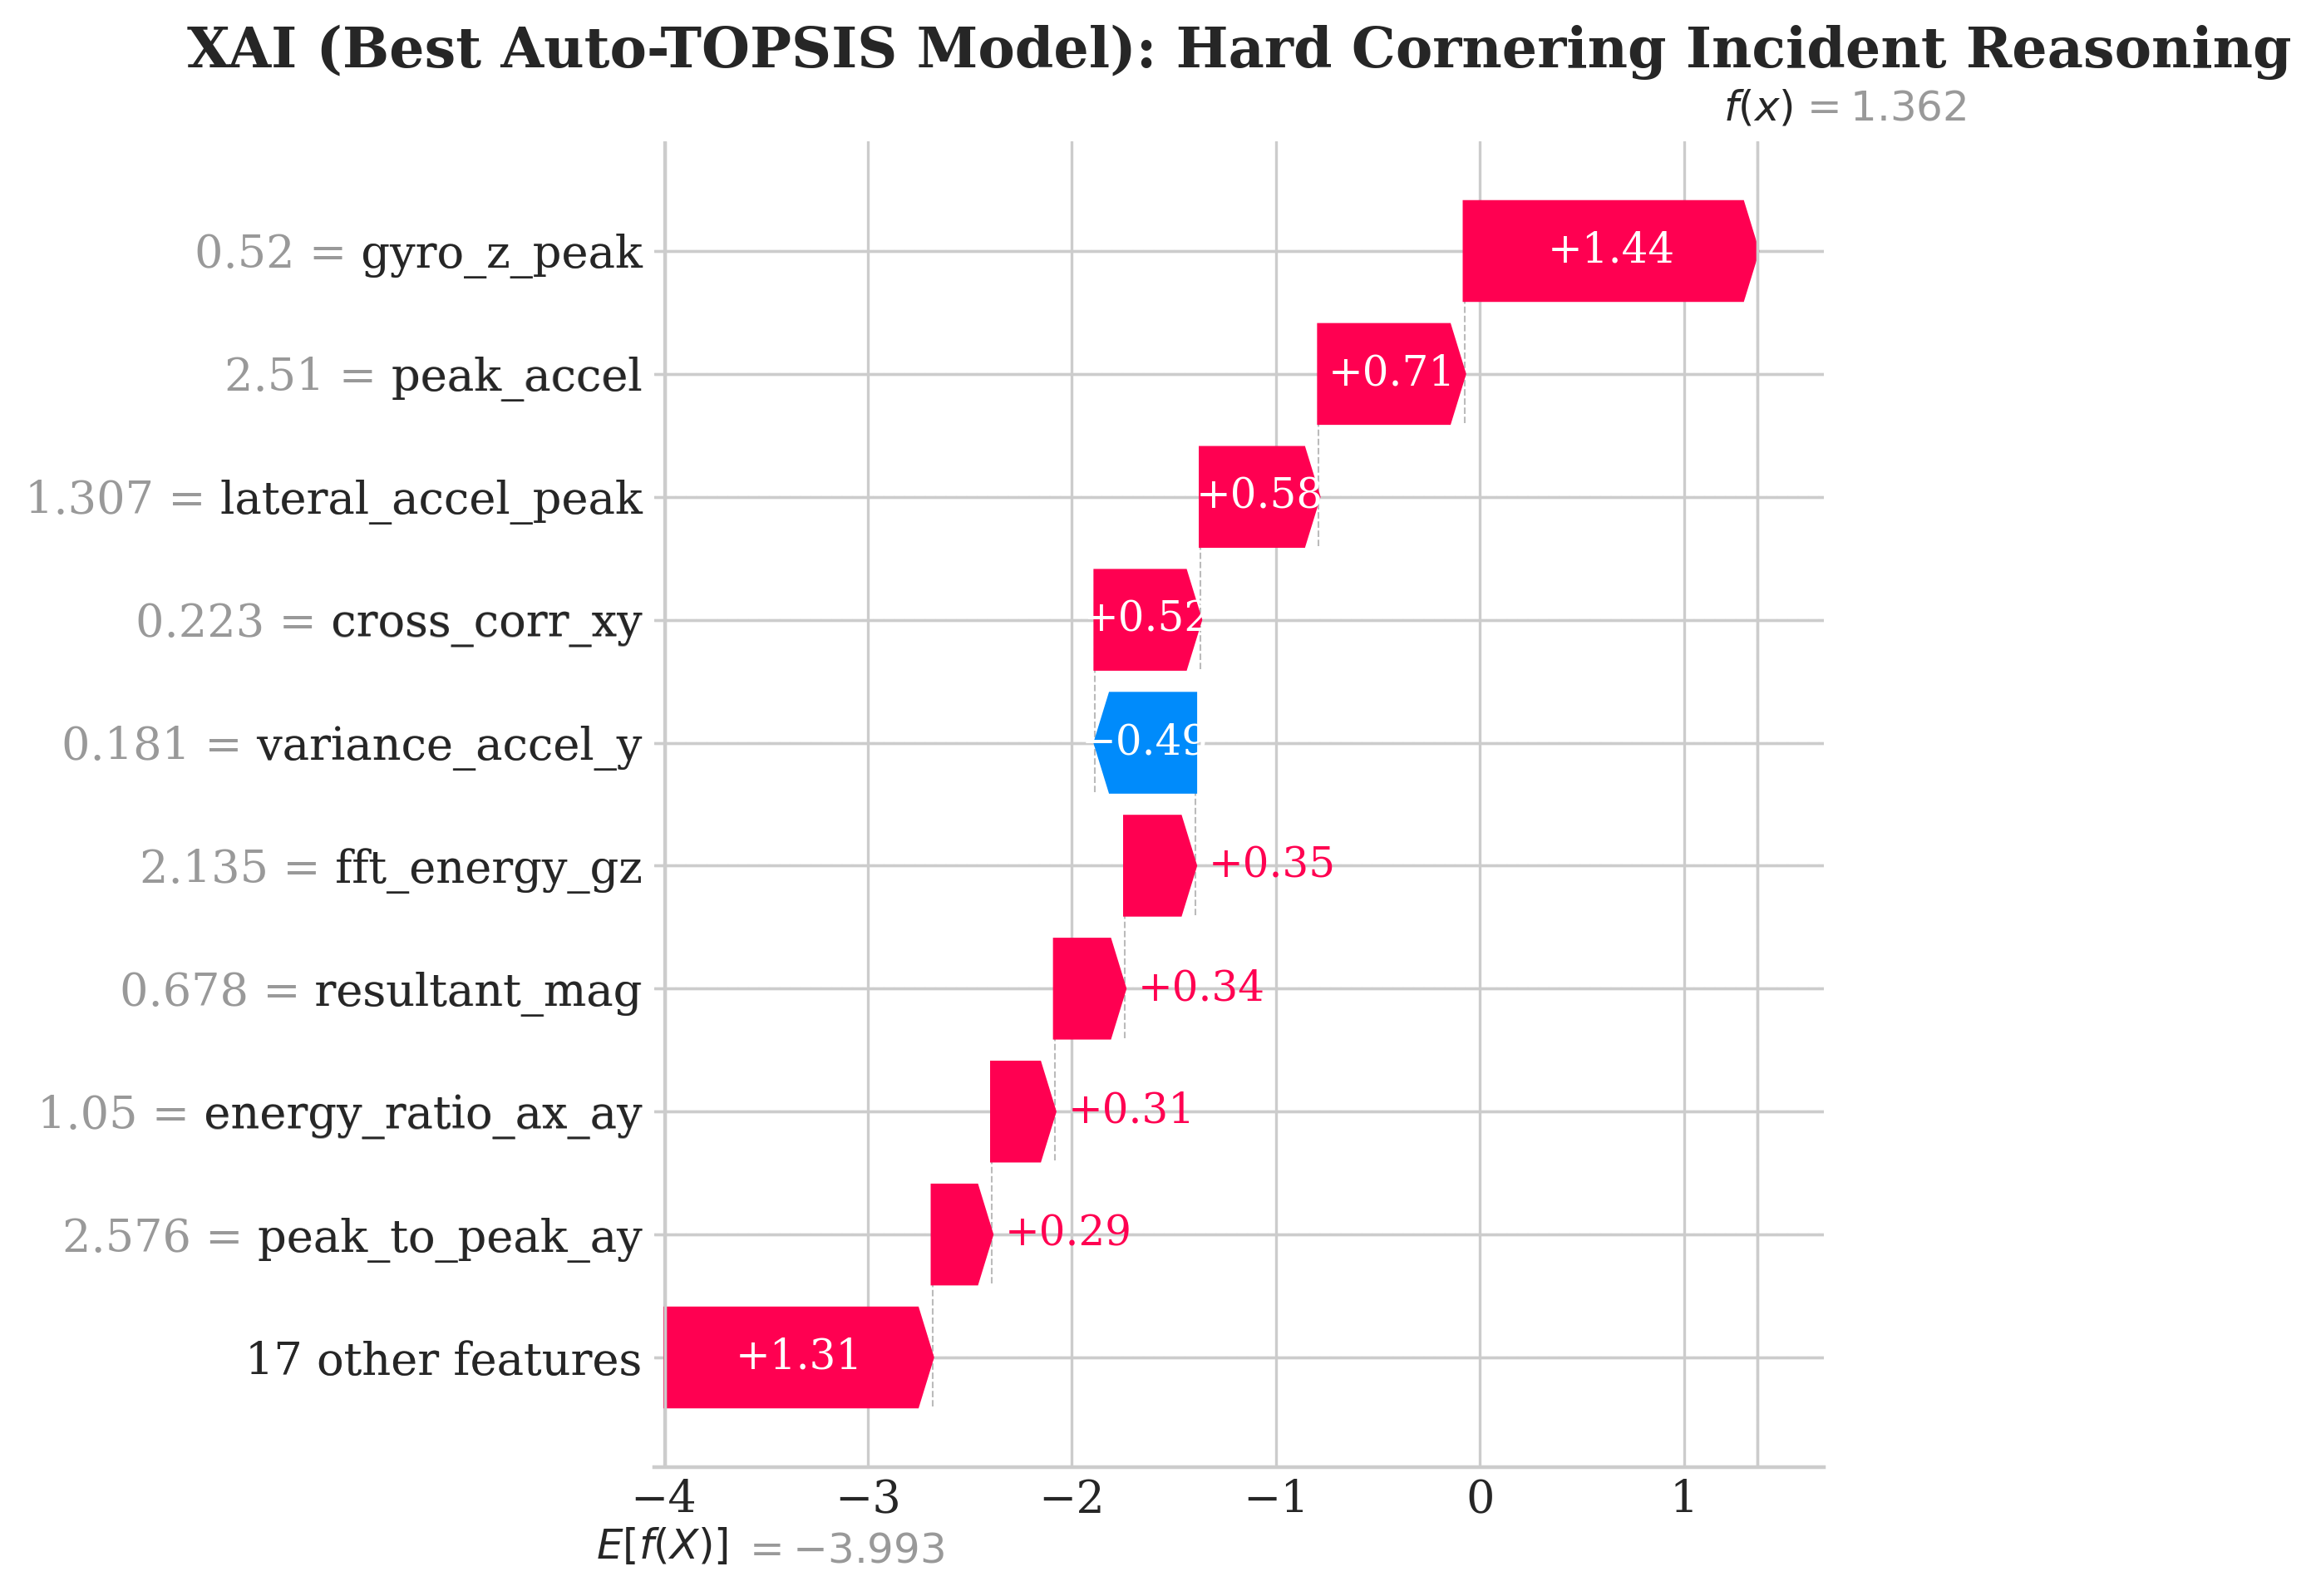

In [18]:
!python src/models/shap_analysis.py

print("\n--- SHAP Feature Importance ---")
display(Image("outputs/plots/shap/shap_global_feature_importance.png"))

print("\n--- SHAP Waterfall Plot (Local Interpretation) ---")
display(Image("outputs/plots/shap/shap_waterfall_example.png"))

## 13. TOPSIS Ranking

In [19]:
# Run the TOPSIS algorithm on the pure-numeric outputs generated by run_baselines.py
!python topsis.py "outputs/reports/topsis_input.csv" "0.05,0.10,0.40,0.20,0.25" "+,+,+,+,+" "outputs/reports/topsis_ranking.csv"

ranking_df = pd.read_csv("outputs/reports/topsis_ranking.csv")
display(ranking_df)

Results successfully saved to 'outputs/reports/topsis_ranking.csv'.


,Model,Accuracy,Precision,Recall,F1 Score,AUC-ROC,Topsis Score,Rank
0,Static Thresholds,0.531569,0.360486,0.725701,0.481694,0.500000,0.0652,6
1,Random Forest,0.989626,0.984440,0.980918,0.982676,0.998829,0.9659,2
2,1D CNN,0.964049,0.981095,0.897436,0.937403,0.990958,0.8237,4
3,Vanilla LSTM,0.960830,0.940750,0.927847,0.934254,0.991263,0.8636,3
4,Unsupervised LSTM Autoencoder,0.299946,0.299946,1.000000,0.461475,0.684723,0.4168,5
5,IntelliCrash (Bi-LSTM Gate),0.993561,0.985790,0.992844,0.989305,0.999619,0.9873,1


## 14. Checkpoint Persistence

In [20]:
import shutil, os
from google.colab import files

dst = "/content/IntelliCrash_Final_Results"

# Delete old folder if exists, start fresh
if os.path.exists(dst):
    shutil.rmtree(dst)
os.makedirs(dst)

# Copy everything into the results folder
shutil.copytree("models", f"{dst}/models")
shutil.copytree("data/processed", f"{dst}/data_processed")
shutil.copytree("outputs", f"{dst}/outputs")
shutil.copy("IntelliCrash_Dataset.csv", f"{dst}/IntelliCrash_Dataset.csv")

print("Zipping results...")
shutil.make_archive("/content/IntelliCrash_Final_Results", 'zip', dst)

print("DONE! Downloading results to your local computer...")
files.download("/content/IntelliCrash_Final_Results.zip")

Zipping results...
DONE! Downloading results to your local computer...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>